<h1 style="text-align: center;"><b>Modern Topics in Interest Rates Modelling</b></h1>

### Roland Grinis


## Overview

This notebook implements a **Hull-White-Heston multi-curve model** for interest rate derivatives calibration.

**Key Features**:
- **Multi-curve framework**: Separate modeling of OIS (risk-free) and Key Rate curves
- **Stochastic volatility**: CIR process for variance, Hull-White-Heston for short rate
- **Market-anchored simulation**: Base curves fixed to market data (no circular calibration)
- **Vectorized pricing**: Efficient caplet and forward rate valuation preserving autodiff
- **No-arbitrage validation**: Martingale tests before calibration

**Model Structure**:
- Short rate: $r_t = f(t) + x_t$, $dx_t = -\lambda x_t dt + \sqrt{v_t} dW_t^x$
- Variance: $dv_t = \kappa(\theta - v_t)dt + \epsilon\sqrt{v_t} dW_t^v$ (CIR)
- Key Rate spread: $s_t = s(t) + k_t$, $dk_t = -\gamma k_t dt + \xi dW_t^k$

In [216]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
plt.style.use("dark_background")
%matplotlib inline

In [217]:
# Add parent directory to Python path for pyquant imports
import sys
sys.path.insert(0, '..')

In [218]:
from pyquant.torch_spline import CubicSpline1D

In [219]:
#data
from pathlib import Path

# Navigate from docs/quant/ap/ up to project root, then into data/
# Current location: docs/quant/ap/
# Need to go: ../../../data/
data_dir = Path('../../../data')

fwd_ois = pd.read_csv(data_dir / 'forward_ois.csv')
fwd_key_rate = pd.read_csv(data_dir / 'forward_key_rate.csv')
vol_key_rate = pd.read_csv(data_dir / 'volatility_key_rate.csv')

## 1. Risk Free Rates (RFRs)

### 1.1 Extended $T$-forward measure

Short (risk-free, OIS) rate $r_t$ gives rise to bank account numeraire:

$$
dB_t = r_t B_t dt, \quad B_t = \exp \left( \int_0^t r_u du \right)
$$

The associcated risk neutral measure $Q$ is called the money-savings measure
Investing in the bank account after maturity, we obtain the extended zero-coupon: 
$$
P_{t,T} = 
\begin{cases}
  \mathbb{E}^Q_t \left[ \exp \left(- \int_{t}^T r_u du \right) \right] , & t\leq T\\
  \exp \left(- \int_{t}^T r_u du \right) = \frac{B_t}{B_T},            & t > T
\end{cases}
$$

The associated risk-neutral measure, denoted $Q^T$, corresponds to the $T$-forward measure for $t \leq T$
and the money-savings measure $Q$ after maturity.   

### 1.2 Backward-looking forward rates

Forward Rate Agreement (FRA) contract has present value:

$$
PV_t = B_t \cdot \mathbb{E}^Q_{t} \left[ \tau \frac{\mathcal{P}_{T-\tau, T} - K}{B_T}  \right]
$$

with forward looking payoff:

$$
\mathcal{P}_{T-\tau, T} \equiv \mathcal{P}_{T-\tau, T} \left[ T' \rightarrow P_{T-\tau, T'} \right]
$$

or backward looking payoff:
$$
\mathcal{P}_{T-\tau, T} \equiv \mathcal{P}_{T-\tau, T} \left[ r_d \in \mathcal{B}(T - \tau, T) \right]
$$
where $\mathcal{B}(T - \tau, T)$ runs over business days in $\left[ T - \tau, T \right)$.

For example, the simple daily-compounded setting-in-arrears rates read:
$$
R_T \coloneqq R(T-\tau, T) = \mathcal{P}_{T-\tau, T} = \frac{1}{\tau} \left( \prod_{t \leq t_n < t+\tau} \left(1 + \tau_n r_{t_n} \right) - 1 \right)
$$

Or the daily arithmetic average setting-in-arrears rates read:

$$
A(T - \tau, T) = \mathcal{P}_{T-\tau, T} = \frac{1}{\tau} \sum_{t \leq t_n < t+\tau} \tau_n r_{t_n} 
$$

Passing to continous modelling:
$$
R(T - \tau, T)\approx  \frac{1}{\tau} \left[ \exp \left( \int_{T - \tau}^T r_u du \right)  - 1\right], \quad A(T - \tau, T)\approx \frac{1}{\tau} \int_{T - \tau}^T r_u du 
$$

and we get the relation:
$$
A(T - \tau, T) \approx \frac{1}{\tau} \log \left(1 + \tau R(T - \tau, T)\right)
$$



Passing to the extended $T$-forward measure, we obtain the compound forward rate as:
$$
R_{t,T} \coloneqq R_t(T - \tau, T) = \mathbb{E}^{Q^T}_{t} \left[  R(T - \tau, T) \right]
$$

which make $PV_t = 0$. We can evaluate the expectation:


* for $t \leq T-\tau$, $ R_{t,T} = \frac{1}{\tau} \left( \frac{P_{t, T - \tau}}{P_{t,T}} - 1\right)$ is analogous to IBOR forward rates.
* for $ T-\tau < t \leq T$, $ R_{t,T} = \frac{1}{\tau} \left( \frac{B_t}{B_{T - \tau} P_{t,T}} - 1\right)$ is daily compounding.
* post maturity $ R_{t,T} \equiv \frac{1}{\tau} \left( \frac{B_{T}}{B_{T - \tau}}  - 1\right)$ is known and fixed.

  
The yield curve $T \rightarrow P_{t,T}$ can be boostrapped from $T \rightarrow  R_{t,T}$ quotes.

The arithmetic average forward rate can be expressed as:
$$
A_{t,T} \coloneqq  A_t(T - \tau, T) = \mathbb{E}^{Q^T}_{t} \left[ \frac{1}{\tau} \log \left(1 + \tau R(T - \tau, T)\right) \right]
$$
and since the payoff is non-linear, $A_{t,T}$ is model dependent. A convexity correction can appear compared to market quotes:
$$
A_{t,T} = \frac{1}{\tau} \log \left(1 + \tau R_{t,T}\right) + \text{Convexity Correction}
$$

#### 1.2.1 Interest Rate Swap
Interest Rate Swap (IRS) based on simple daily-compounding backward rates values:
$$
PV_t = \sum_{i=1}^n \tau_i P_{t,T_i}R_t(T_{i-1}, T_i) - K \cdot  \sum_{j=1}^m \tau'_i P_{t, T'_j}
$$
with floating leg tenors $T_0, \dots, T_n$ and fixed leg $T'_0, \dots, T'_m$ tenors. 

For $t < T_0$ forward swap rate with associated present value of a basis point evaluates:
$$
S_t(T_0, T_n) = \frac{P_{t,T_0} - P_{t,T_n}}{\text{PVBP}(t)} , \quad \text{PVBP}(t) = \sum_{j=1}^m \tau'_j P_{t, T'_j}
$$

Consider the OIS FRA quotes:

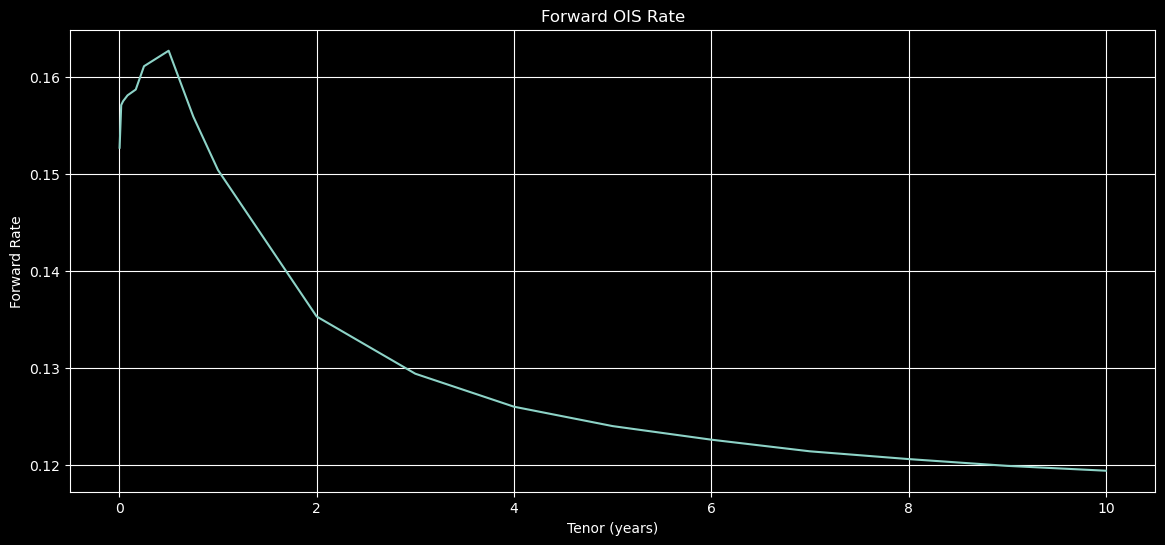

In [180]:
fwd_ois.set_index('tenor').sort_index()['forward_rate'].plot(
    title='Forward OIS Rate', 
    grid=True, 
    figsize=(14, 6),
    xlabel='Tenor (years)',
    ylabel='Forward Rate'
)
plt.show()

Compute the yield curve $T \rightarrow P_{t,T}$  using the above quotes.

In [220]:
def build_ois_yield_curve_from_now_starting(forwards, tenors):
    zcbs = 1 / (1 + tenors * forwards)
    return CubicSpline1D(tenors, zcbs)

ois_yield_curve = build_ois_yield_curve_from_now_starting(
    torch.tensor(fwd_ois.forward_rate.values),
    torch.tensor(fwd_ois.tenor.values)
)

Let's compute IRS swap rates with tenors ranging from 1M to 10Y starting overnight, to bootstrap the yield curve $P_{t,T}$ back. In fact, the swap rate formula leads to a linear equation:
$$
P_{t,T_m} + \tau S_t(T_{1,\dots,m}) \sum_{j=1}^m P_{t, T_j} = 1
$$
where the coupons $P_{t,T_i}$ are variables and different swap quotes $S_t(  T_{m, \dots, n})$ lead to a system of linear equations that can be solved using the SVD method for $P_{t,T_i}$. One can then fit a polynomial model to smooth out the yield curve.

In [221]:
tau = 1/12
n_coupons = 120
maturities = tau * torch.ones(n_coupons).cumsum(0)
num_months = 1 + torch.arange(0, n_coupons, step=1)
n_tenors = num_months.numel()
A = torch.zeros((n_tenors,120))
for i in range(n_tenors):
    n_months = num_months[i].item()
    payment_dates = (1 + torch.arange(n_months)) * tau
    zcb_last = ois_yield_curve.evaluate(payment_dates[-1]).sum()
    tau_swap_rate = (1 - zcb_last) / ois_yield_curve.evaluate(payment_dates).sum()
    for j in range(n_months):
        A[i][j] = tau_swap_rate.item()
    A[i][n_months-1] += 1
U, S, Vh = torch.linalg.svd(A)

In [222]:
bootstrap_zcb = torch.mv(Vh[:n_tenors].t(), torch.mv(U.t(), torch.ones(n_tenors)) / S)

In [223]:
pd.DataFrame({
    'maturities' : maturities,
    'zcbs': ois_yield_curve.evaluate(maturities).flatten(),
    'bootstrap': bootstrap_zcb.numpy()}).set_index('maturities').plot(legend=True, grid=True, figsize=(20,10));

### 1.3 Forward Market Model (FMM)
As we approach maturity $T$, backward-looking rates settle to constant, and we need to choose a cutoff function to dampen volatility. 
  
A typical example is the linear cutoff $g_{t,T} = (T-t)^+ / \tau $ for $t \in (T-\tau, T)$ with $g_{t,T} \equiv 1$ for $t \leq T-\tau$ and $g_{t,T} \equiv 0$, $t \geq T$.  
  
In extended $T$-forward measure:
$$
dR_{t,T} = g_{t,T} \sigma_{t,T} (R_{t,T}) dW_t^{Q^T} \quad \text{martingale,}
$$

where $\sigma_{t,T} \equiv \sigma^T$ (Bachelier), or $\sigma_{t,T} \equiv \sigma^T R_{t,T}$ (Black), or  $\sigma_{t,T} \equiv \sigma^T (R_{t,T})^{\beta}$ (CEV), or Dupire local vol, or stochastic vol etc. with (multi-dimensional) Brownian motion $W_{t,T}$

In money-savings numeraire $B_t$, we get the drift:
$$
dR_{t,T} = g_{t,T} \sigma_{t,T}(R_{t,T}) \left[
\sum_{T' < T}\rho_{T',T} \frac{\tau' g_{t,T'} \sigma_{t,T'}(R_{t,T'})}{1 + \tau' R_{t,T'} } dt + dW_t^Q
\right]
$$
where the sum runs over shorter tenors and $\rho$ holds the correlation structure of the curve.

#### 1.3.1 Caplet Pricing

Using $P_{t,T}$ as numeraire, for simply-compound rates:

$$
V^{\text{Caplet}}_t \left[ R_{t,T}, K \right] = P_{t,T} \mathbb{E}_{t}^{Q^T} \left[ \tau \left( R(T-\tau, T) - K \right)^+ \right] 
$$

For arithmetic average compound rates, the choice of cutoff $g_{t,T}$ influence directly the convexity correction. 
One should attempt to choose it such that we have:
$$
V^{\text{Caplet}}_t \left[ A_{t,T}, K \right] = P_{t,T} \mathbb{E}_{t}^{Q^T} \left[ \tau \left( A(T-\tau, T) - K \right)^+ \right] =  P_{t,T} \mathbb{E}_{t}^{Q^T} \left[  \left( \log \left(1 + \tau R(T - \tau, T)\right)  - \tau K \right)^+ \right] 
$$ 

As reference, using the linear cutoff:
$$
\hat{g}_{t,T}^2 \coloneqq \int_{t,T} g_{t,T}^2(s)ds = 
\begin{cases}
  T - t - \frac{2}{3}\tau,  & t\leq T-\tau \\
  \frac{(T-t)^3}{3\tau^2},  & t > T - \tau
\end{cases}
$$

Bachelier model:
$$
dR_{t,T} = g_{t,T} \sigma dW_t^{Q^T}, \quad R(T-\tau, T) \sim \mathcal{N}\left(R_{t,T}, (\sigma\hat{g}_{t,T})^2 \right) 
$$ 


Black model:
$$
dR_{t,T} = g_{t,T} R_{t,T} \sigma dW_t^{Q^T}, \quad R(T-\tau, T) = R_{t,T} \exp \left( - \frac{(\sigma\hat{g}_{t,T})^2 }{2} + \mathcal{N}\left(0, (\sigma\hat{g}_{t,T})^2 \right)  \right)
$$

Market makers formula convention for arithmetic-average compound rates:
$$
V^{\text{Caplet}}_t \left[ A'_{t,T}, K \right] = \tau P_{t,T}\left[ \left( A'_{t,T} - K\right) \Phi\left(\frac{A'_{t,T} - K}{\sigma \hat{g}_{t,T} }\right) + \sigma \hat{g}_{t,T} \phi\left(\frac{A'_{t,T} - K}{\sigma \hat{g}_{t,T} }\right)\right]
$$
which is the Bachelier model (normal volatility, $\Phi$ and $\phi$ are normal distribution CDF and PDF respectively), or:
$$
V^{\text{Caplet}}_t \left[ A'_{t,T}, K \right] = \tau P_{t,T}\left[ A'_{t,T} \Phi\left(d_{+}\right) - K \Phi \left(d_{-} \right) \right], \quad d_{\pm} = \frac{\log (A'_{t,T} / K) \pm (\sigma \hat{g}_{t,T})^2 / 2 }{\sigma\hat{g}_{t,T}}
$$
with the Black model (log-normal volatility). No convexity correction is taken into account. However, the discounting $P_{t,T}$ is done with respect to the OIS curve, even if  $A'_{t,T}$ correspond to a different RFR rate (e.g. a Key Rate). 

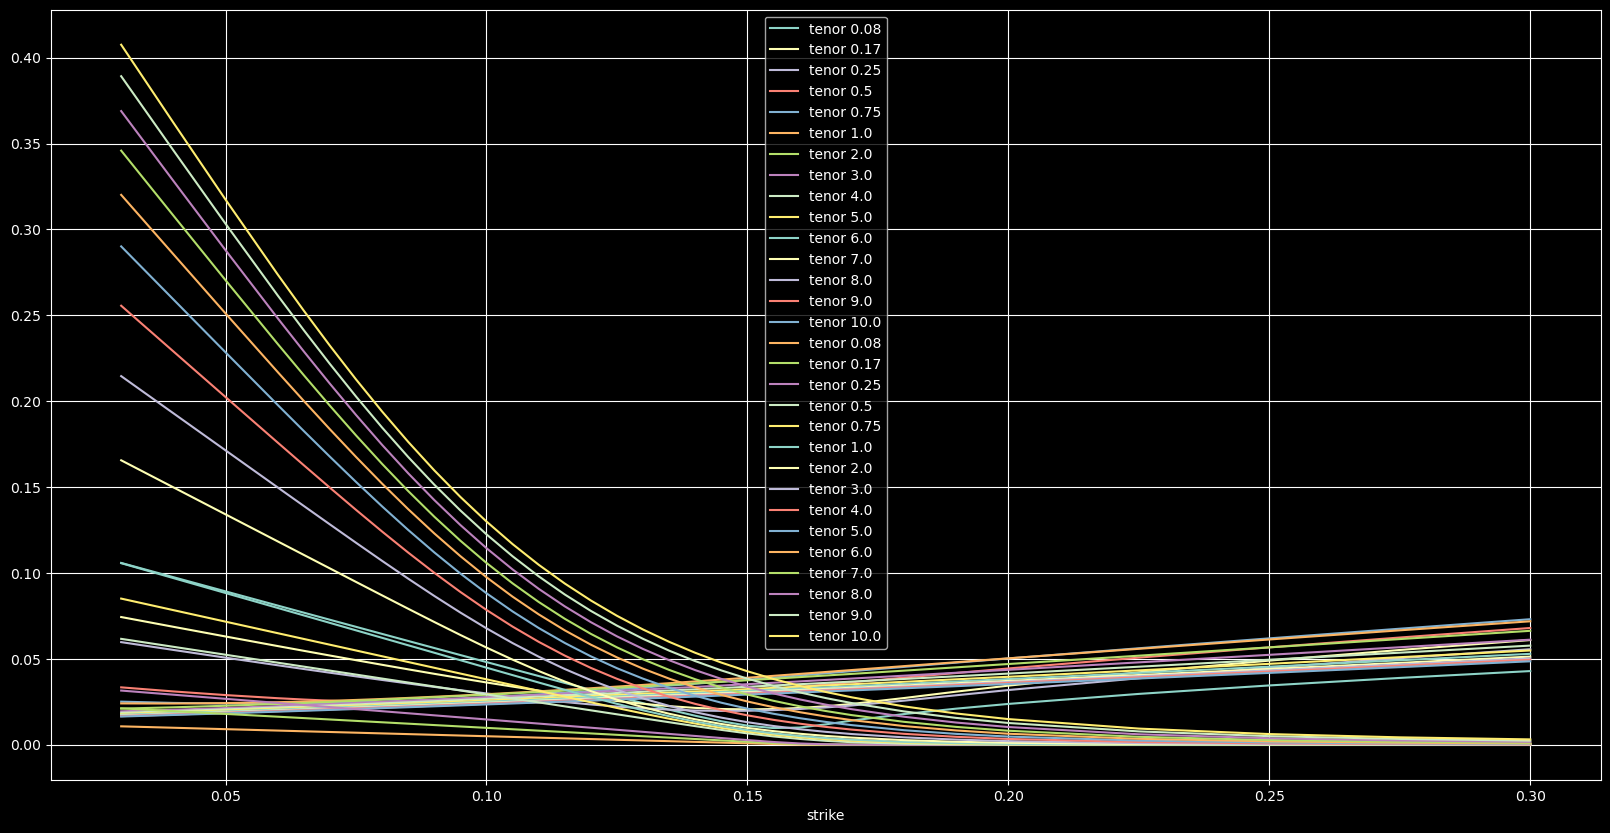

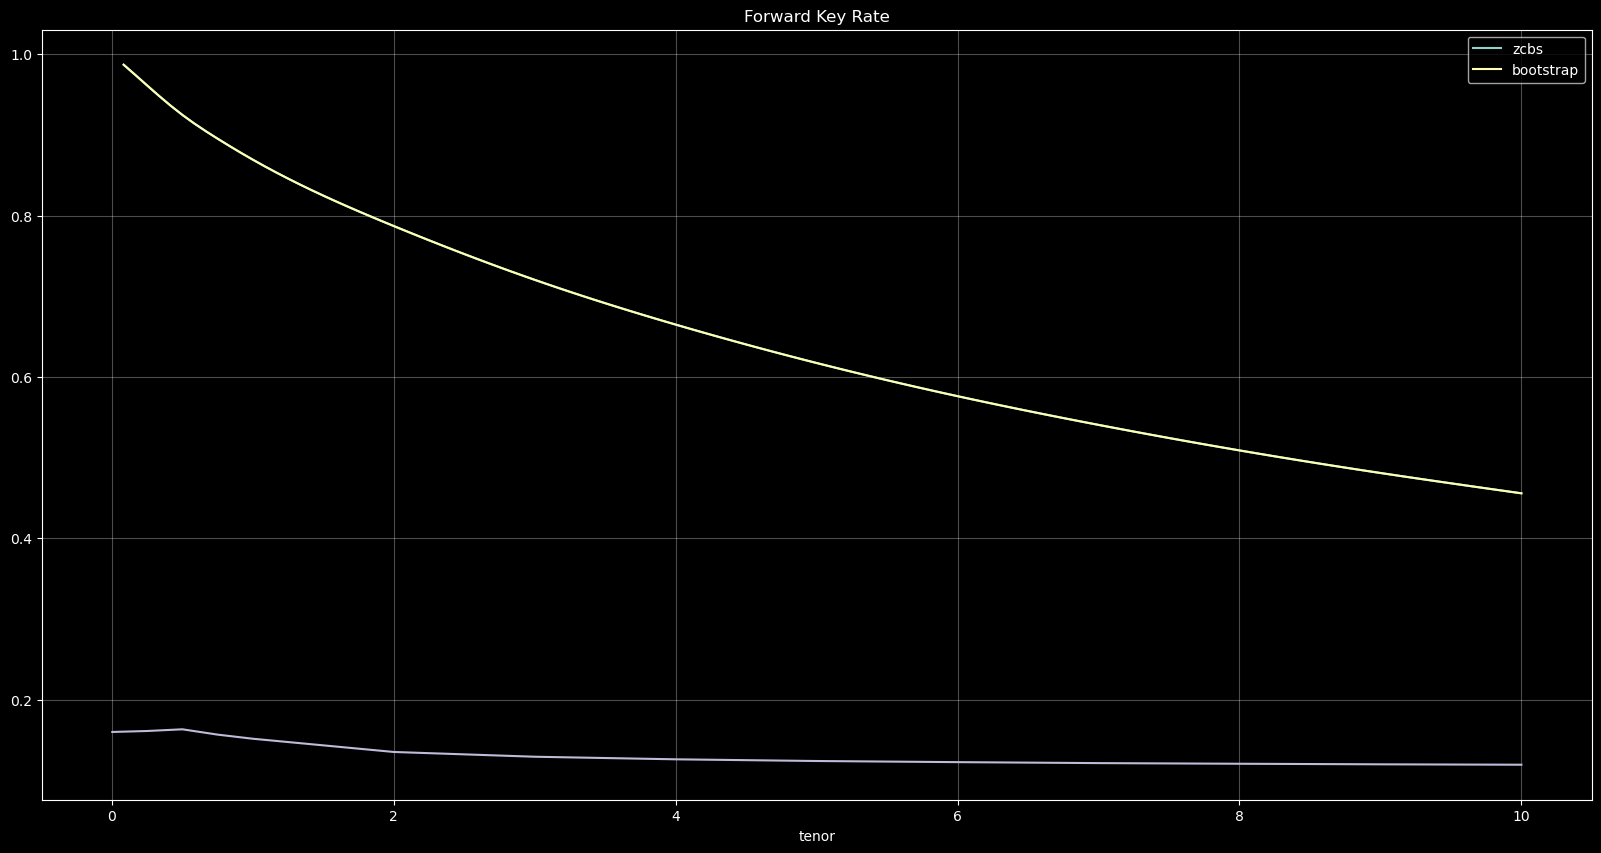

In [224]:
fwd_key_rate.set_index('tenor').sort_index().forward_rate.plot(title='Forward Key Rate', grid=True, figsize=(20,10));
plt.grid(True, alpha=0.3)
plt.show()

In [225]:
for k,v in vol_key_rate.groupby('time_to_maturity'):
    v.set_index('strike').sort_index().implied_normal_vol.rename(f'tenor {round(k,2)}').plot(legend=True, grid=True, figsize=(20,10));

In [226]:
def build_fwd_curve(forwards, time_to_maturity):
    return CubicSpline1D(time_to_maturity, forwards)

def caplet_premium_from_now_starting(vol_surface, key_rate_fwd_curve, ois_yield_curve):
    time_to_maturity = torch.tensor(vol_surface.time_to_maturity.values)
    tenor = torch.tensor(vol_surface.tenor.values)
    g_hat = torch.sqrt(time_to_maturity - (2/3) * tenor)

    strike = torch.tensor(vol_surface.strike.values)
    fwd = key_rate_fwd_curve.evaluate(time_to_maturity).flatten()
    discount = ois_yield_curve.evaluate(time_to_maturity).flatten()
    iv = torch.tensor(vol_surface.implied_normal_vol.values)

    sigma_moneyness = (fwd - strike) / (iv * g_hat)

    normal = torch.distributions.Normal(0,1)
    Phi = normal.cdf
    log_phi = normal.log_prob

    pv = tenor * discount * ( (fwd - strike) * Phi(sigma_moneyness) + iv * g_hat * torch.exp(log_phi(sigma_moneyness)) )
    return torch.maximum(pv,torch.tensor(0.))

In [227]:
key_rate_fwd_curve = build_fwd_curve(
    torch.tensor(fwd_key_rate.forward_rate.values),
    torch.tensor(fwd_key_rate.time_to_maturity.values)
)

In [228]:
vol_key_rate['pv'] = caplet_premium_from_now_starting(vol_key_rate, key_rate_fwd_curve, ois_yield_curve).numpy()

In [229]:
for k,v in vol_key_rate.groupby('time_to_maturity'):
    v.set_index('strike').sort_index().pv.rename(f'tenor {round(k,2)}').plot(legend=True, grid=True, figsize=(20,10));

### 1.4 Short Rate Models: Hull-White

Dynamics in money-savings risk-neutral measure $Q$ are given by:
$$
dr_t = \left( \theta_t - \lambda r_t \right) dt + \sigma dW_t
$$

with $\theta_t$ fixed by the HJM no-arbitrage condition. This can be rewritten as affine process:

$$
r_t = \alpha_t + x_t 
$$

where the deterministic part follows the HJM condition:
$$
\alpha_T = - \frac{\partial}{ \partial T}\log P_{t,T} + \frac{\sigma^2}{2 \lambda^2} \left( 1- e^{\lambda (T-t)} \right)
$$
and the stochastic part:
$$
dx_t = - \lambda x_t dt + \sigma dW_t
$$
which is simply a Gaussian:
$$
x_T \sim \mathcal{N} \left( x_t e^{-\lambda(T-t)}, \quad \frac{\sigma^2}{2 \lambda} \left( 1- e^{-2\lambda (T-t)} \right) \right)
$$

Changing to the $T$-forward measure $Q^T$: 
$$
dx_t = - \left( \frac{\sigma^2}{\lambda} \left(1 - e^{-\lambda(T-t)} \right) + \lambda x_t \right) dt + \sigma dW^T_t
$$

which is also a gaussian with mean:
$$
\mathbb{E}^{Q^T}_{t} \left[ x_{t+\Delta} \right] = x_t e^{-\lambda \Delta} - \frac{\sigma^2}{\lambda^2} \left(1 - e^{-\lambda \Delta} \right) - \frac{\sigma^2}{2\lambda^2} \left(e^{-\lambda(T-t-\Delta)} - e^{-\lambda(T-t+\Delta)} \right) 
$$
and variance $\frac{\sigma^2}{2 \lambda} \left( 1- e^{-2\lambda \Delta} \right)$ as in measure $Q$.

In [230]:
timeline = torch.linspace(0, 10., 3651) # 10 years Actual/365 day

In [231]:
def generate_hull_white(
        n_paths: int,
        timeline: torch.Tensor,
        init_state: torch.Tensor,
        lam: torch.Tensor,
        sigma: torch.Tensor
) -> torch.Tensor:
    dt_steps = timeline.diff()
    n_steps = dt_steps.shape[0]
    paths = torch.empty((n_paths, n_steps + 1), dtype=init_state.dtype)
    paths[:, 0] = init_state
    for i in range(0, n_steps):
        x = paths[:, i].clone()
        Z = torch.randn_like(x)
        dt = dt_steps[i]
        x_next = x * torch.exp(- dt * lam) + Z * torch.sqrt( sigma * sigma * (1 - torch.exp(- 2 * dt * lam)) / (2 * lam) ) 
        paths[:, i+1] = x_next
    return paths

In [232]:
x0 = torch.tensor(0., requires_grad = True)
lam = torch.tensor(1., requires_grad = True)
sigma = torch.tensor(0.3, requires_grad = True) 

In [233]:
hw_paths = generate_hull_white(1000, timeline, x0, lam, sigma)

In [234]:
pv = torch.maximum(hw_paths[:,-1] - 0. , torch.tensor(0.)).mean()
pv

tensor(0.0860, grad_fn=<MeanBackward0>)

In [235]:
grad = torch.autograd.grad(pv, [x0, lam, sigma])
grad

(tensor(2.3336e-05), tensor(-0.0422), tensor(0.2866))

#### 1.4.1 The Hull-White-Heston model

To price the volatility smile we rely on stochastic volatility models such as the Heston Model, which combined with Hull-White looks like:

$$
\left\{
\begin{array}{l}
    dx_t = - \lambda x_t dt + \sqrt{v_t} \text{d}W_t^x,  \\
    dv_t =  \kappa (\theta - v_t)\text{d}t + \varepsilon \sqrt{v_t} \text{d} W_t^v,
\end{array}\right.
$$
with no correlation between the Brownian motions $dW_t^x \cdot dW_t^v = 0$, as this breaks the affinity of the process when changing from measure $Q$ to the $T$-forward $Q^T$: 
$$
\left\{
\begin{array}{l}
    dx_t =  - \left( \frac{v}{\lambda} \left(1 - e^{-\lambda(T-t)} \right) + \lambda x_t \right) dt + \sqrt{v_t} \text{d}W_t^x,  \\
    dv_t =  \kappa (\theta - v_t)\text{d}t + \varepsilon \sqrt{v_t} \text{d} W_t^v,
\end{array}\right.
$$

The short rate itself:
$$ 
r_t = \alpha_t + x_t 
$$ 
where the HJM condition on $\alpha_t$ is described in the multiple-curve framework below.

Stochastic variance is an CIR process with non-central chi-squared distribution:
$$
\mathbb{P}\left(v_{t + \Delta}<v \mid v_{t}\right) \quad = \quad F_{\chi'^{2}}\left(\frac{4 \kappa v}{\varepsilon^{2}\left(1-e^{-\kappa \Delta}\right)} ; \frac{4 \kappa \theta}{\varepsilon^{2}}, \frac{4 v_{t} \kappa e^{-\kappa \Delta}}{\varepsilon^{2}\left(1-e^{-\kappa \Delta}\right)}\right) \quad
$$
over a time step $\Delta$, and admits an almost exact QE simulation scheme.  

Since no correlation leaks can occur, the Euler scheme is sufficient to evolve $x_t$ and $v_t$:
$$
x_{t+\Delta} \sim \mathcal{N} \left( x_t e^{-\lambda \Delta}, \quad \frac{v_t}{2 \lambda} \left( 1- e^{-2\lambda \Delta} \right) \right)
$$
and similarly in $T$-forward measure.


In [236]:
from pyquant.heston_sim import generate_cir

In [237]:
v0 = torch.tensor(0.65, requires_grad = True)
theta = torch.tensor(1., requires_grad = True)
kappa = torch.tensor(1.3, requires_grad = True) 
epsilon = torch.tensor(1., requires_grad = True) 

In [238]:
cir_paths = generate_cir(1000, timeline, v0, kappa, theta, epsilon, 1e-6)

In [239]:
def generate_hull_white_heston(
        n_paths: int,
        timeline: torch.Tensor,
        init_state: torch.Tensor,
        lam: torch.Tensor,
        var: torch.Tensor
) -> torch.Tensor:
    dt_steps = timeline.diff()
    n_steps = dt_steps.shape[0]
    assert(var.shape == (n_paths, n_steps + 1))
    paths = torch.empty((n_paths, n_steps + 1), dtype=init_state.dtype)
    paths[:, 0] = init_state
    for i in range(0, n_steps):
        x = paths[:, i].clone()
        Z = torch.randn_like(x)
        dt = dt_steps[i]
        sigma_2 = var[:, i]
        x_next = x * torch.exp(- dt * lam) + Z * torch.sqrt( sigma_2 * (1 - torch.exp(- 2 * dt * lam)) / (2 * lam) ) 
        paths[:, i+1] = x_next
    return paths

In [240]:
x0 = torch.tensor(0., requires_grad = True)
lam = torch.tensor(1., requires_grad = True)

In [241]:
hwh_paths = generate_hull_white_heston(1000, timeline, x0, lam, cir_paths)

In [242]:
pv = torch.maximum(hwh_paths[:,-1] - 0. , torch.tensor(0.)).mean()
pv

tensor(0.2736, grad_fn=<MeanBackward0>)

In [243]:
grad = torch.autograd.grad(pv, [x0, lam, v0, kappa, theta, epsilon])
grad

(tensor(2.2655e-05),
 tensor(-0.1407),
 tensor(6.3428e-07),
 tensor(0.0092),
 tensor(0.1470),
 tensor(-0.0205))

## 2. Multi-Curve Models

This section covers affine multi-curve models for interest rate derivatives, focusing on:
1. **Theory**: IBOR rates, forward spreads, and HJM conditions
2. **Key Rate Model**: Arithmetic-average compounding with CIR-Hull-White-Heston dynamics
3. **Implementation**: Market-anchored simulation and vectorized pricing
4. **Calibration**: Simultaneous optimization of volatility parameters and forward curve

### 2.1 Affine multi-curve models and IBOR rates

The short rate is given by:
$$
r_t = f(t) + \lambda^T \textbf{x}_t
$$
where $\textbf{x}_t$ is an affine process and $\lambda$ is constant. The latter drive also the instantaneous forward spread rates to other curves:
$$
s_t^{\delta} = s^{\delta}(t) + \gamma_{\delta}^T \textbf{x}_t
$$
enumerated by $\delta$, with $\gamma_{\delta}$ constant. If those spreads corresponds to IBOR rates, then $\delta$ are the tenors, and we require:
$$
0 \leq s_t^{\delta_i}  \leq s_t^{\delta_j}, \quad  \delta_i < \delta_j
$$
in which case we can calibrate to the available ZCB curves:
$$
T \rightarrow P_{t,T} = \mathbb{E}_t \left[ e^{- \int_{t,T} r_u du} \right], \quad P^\delta_{t,T} = \mathbb{E}_t \left[ e^{ - \int_{t,T} \left(r_u + s^{\delta}_u \right)du} \right]
$$

where $P_{t,T}$ is the OIS curve, and the other correspond to IBOR forward rates at different tenors:
$$
L_t(T-\delta, T)=  \frac{P_{t,T-\delta}^\delta - P_{t,T}^\delta}{\delta \cdot P_{t,T}^\delta} 
$$

Denoting the forward spreads:
$$
S^{\delta}_t(T) = \frac{1 + \delta \cdot L_t(T-\delta, T)}{1 + \delta \cdot L^D_t(T-\delta,T)} = \frac{P_{t,T-\delta}^\delta}{P_{t,T}^\delta} \frac{P_{t,T}}{P_{t,T-\delta}}
$$
where $L^D_t(T-\delta, T) =   \frac{P_{t,T-\delta} - P_{t,T}}{\delta P_{t,T} }$ is the forward looking RFR.

We recall that the instantaneous forward is given by:
$$
f_{t,T} = - \frac{\partial}{\partial T} \log P_{t,T}
$$

whereas the instantenous multiplicative spread:
$$
s^{\delta}_{t,T} =  \frac{\partial}{\partial T} \log S^\delta_t(T)
$$

note the difference is signs, as heuristically the instantenous forward for the tenor-$\delta$ curve is  $f_{t,T}^\delta = f_{t,T} + s^{\delta}_{t,T}$.

The HJM condition in that case reduces to:
$$
f(t) = f_{t,T} - \bar{f}_{t,T}, \quad s^{\delta}(t) = \frac{\partial}{\partial t} \log S^\delta _0(t) - \frac{\partial}{\partial t} \log \bar{S}^\delta _0(t) 
$$
where the base curves $\bar{P}_{0,t}$ and $\bar{S}^\delta _0(t)$ are obtained from a model where $f(t)\equiv 0$ and $s^{\delta}(t) \equiv 0$.


#### 2.1.1 Linear Products

IBOR quotes typically come from FRAs, whose present value at strike $K$ is given by:
$$
PV_t\left[K \right] = P_{t,T} S^{\delta}_t(T)- (1 + \delta K) P_{t, T+\delta}
$$

Using IRSs quotes, one solves for forward spreads $S^{\delta}_t(T)$ directly, as the former evaluates to:
$$
PV_t \left[\delta,  \delta', K\right] = \sum_{i \geq 1} \left( P_{t, T_{j-1}}  S^{\delta}_t(T_{j-1}) -  P_{t, T_{j}} \right) - \delta' K \sum_{j\geq 1} P_{t, T'_j}
$$
where $\delta = T_{i} - T_{i-1}$ is the floating leg tenor and $\delta' = T'_{j} - T'_{j-1}$ is the fixed leg tenor. 

#### 2.1.2 Model with CIR processes
A typical example can be obtained using self-exciting CIR processes for the forward spreads and Hull White dynamics for the rate:
$$
s_t^{\delta_j} = s^{\delta_j}(t) + \sum_{i \leq j} \gamma_i x_{t}^i, \quad \gamma_i \geq 0, \quad dx_{t}^i= \kappa_i (\theta_i - x_{t}^i) dt + \epsilon_i \sqrt{x_{t}^i} dW_t^i
$$
where tenors $\delta_{1} < \delta_{2} < \dots < \delta_{n}$ are in increasing order. 

The short rate  follows the Hull-White-Heston multi-factor model:
$$
r_t = f(t) + x_t^0, \quad dx_{t}^0 = - \lambda_0 x_{t}^0 dt + \sum_{i=1}^n \lambda_i \sqrt{x_{t}^i} dW_t^i
$$
where $\lambda_1^2 + \dots + \lambda_n^2 =1$, and all Brownian motions $W_t^i$ are independent.


### 2.2 Modelling Arithmetic-Average Compounding on a Key Rate

We are not confined to model IBOR rates with spreads $s_t^{\delta}$. In fact, we can choose any other curve, in which case we will need to fit whatever market quotes are available to us. 

In our case, we have a forward curve for arithmetic-average backward looking $A_{t,T}$ on a Key Rate, which is different from the OIS $r_t$ for which we also have forward curve. And we need to capture the smile of a volatility surface on $A_{t,T}$. 

We can add to the Hull-White-Heston model a stochastic spread between OIS short rate and the Key Rate:
$$
r_t = f(t) + x_t, \quad dx_{t} = - \lambda x_{t} dt + \sqrt{v_t} dW_t^x, \quad dv_t =  \kappa (\theta - v_t)dt + \varepsilon \sqrt{v_t} dW_t^v
$$
as above and the spread follows a mean-reversion processess near zero:
$$
s_t = s^a(t) + k_t, \quad dk_t =  - \gamma k_t dt + \xi dW_t^k
$$
with all Brownian motions $W_t^x, W_t^v$ and $W_t^k$ independent. 

Note that the spread $s^a(t)$ does not depend on a tenor $\tau$ as we are working with RFR rates, and therefore can be computed from any tenor. The most convenient is the one corresponding to time to maturity $\tau = T-t$, and in fact it is the one which is typically quoted. In that case:
$$
s^a(t) = \left( f_{t,T}^a - f_{t,T} \right) - \left( \bar{f}_{t,T}^a - \bar{f}_{t,T} \right)
$$
where the top-bar terms are the ones obtained from the model with $s^a(t) \equiv 0$ and $f(t) \equiv 0$ as above.

#### Example 2.2.1

Obtain the OIS instantaneous rates $f_{t,T}$ from:

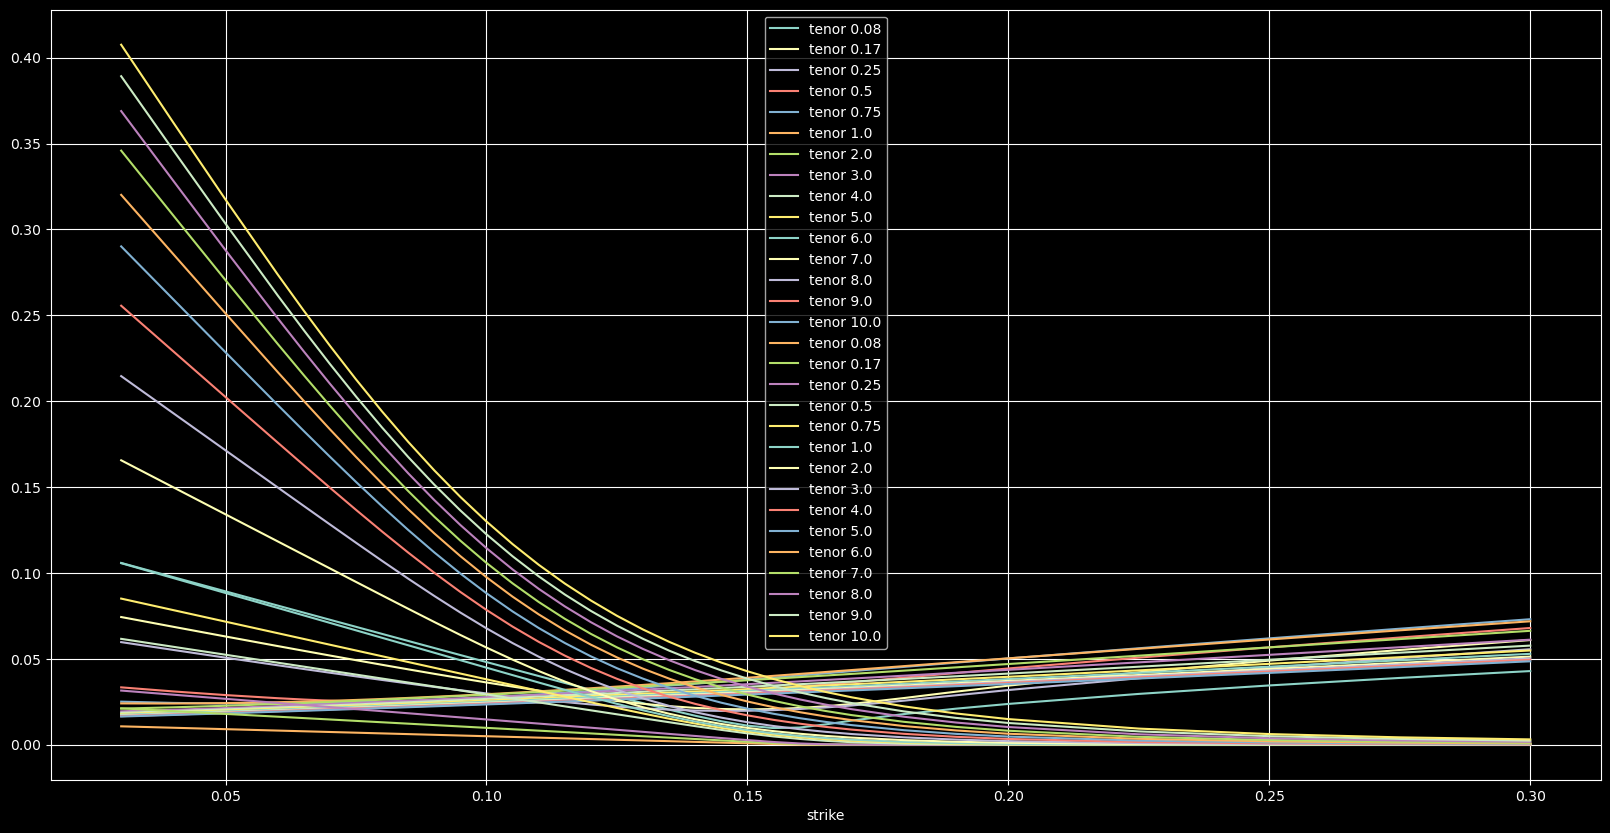

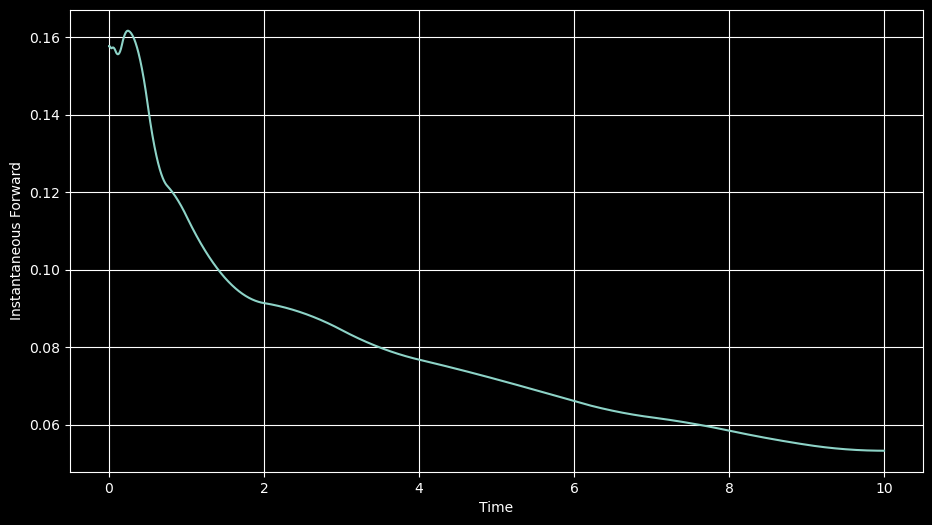

In [244]:
def build_ifwd_curve_from_now_starting(forwards, tenors):
    zcbs = 1 / (1 + tenors * forwards)
    log_zcbs = torch.log(zcbs)
    return CubicSpline1D(tenors, - log_zcbs)

ois_ifwd_curve = build_ifwd_curve_from_now_starting(
    torch.tensor(fwd_ois.forward_rate.values),
    torch.tensor(fwd_ois.tenor.values)
)

plt.figure(figsize=(11, 6))
plt.plot(timeline,ois_ifwd_curve.derivative(timeline).detach().numpy())
plt.ylabel('Instantaneous Forward')
plt.xlabel('Time')
plt.grid()
plt.show()

Ignoring the convexity correction, obtain the Key Rate instantaneous rates $f^a_{t,T}$ from:

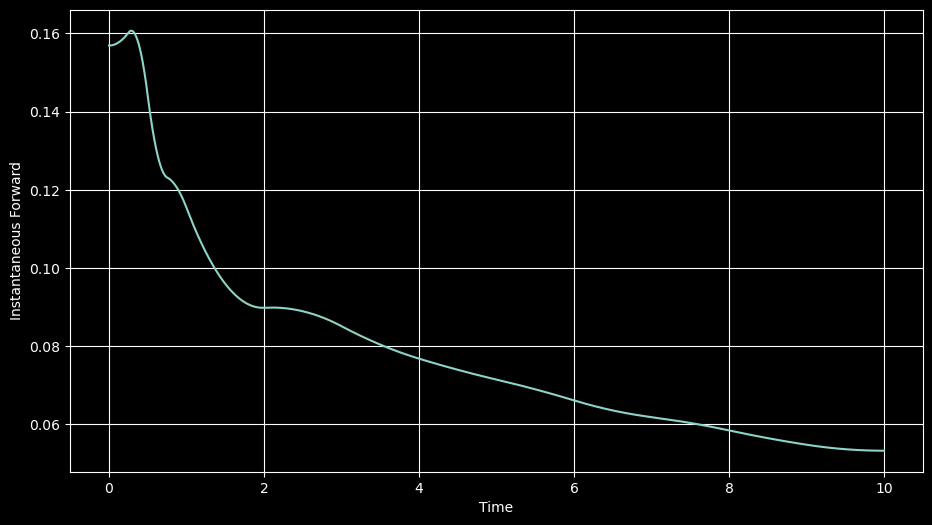

In [245]:
def build_ifwd_key_curve_from_now_starting(key_ifwd_values, key_fwd_values, tenors):
    clamp_ifwd_vals = torch.clamp(key_ifwd_values, min=key_fwd_values-0.01, max=key_fwd_values+0.01)
    return build_ifwd_curve_from_now_starting(clamp_ifwd_vals, tenors)

key_ifwd_values = torch.tensor(fwd_key_rate.forward_rate.values, requires_grad=True)
key_ifwd_curve = build_ifwd_key_curve_from_now_starting(
    key_ifwd_values, torch.tensor(fwd_key_rate.forward_rate.values), torch.tensor(fwd_key_rate.tenor.values))

plt.figure(figsize=(11, 6))
plt.plot(timeline,key_ifwd_curve.derivative(timeline).detach().numpy())
plt.ylabel('Instantaneous Forward')
plt.xlabel('Time')
plt.grid()
plt.show()

Obtain the parameters for the factors $x_t$, $v_t$ and $k_t$ as to fit the Caplet prices:
$$
V^{\text{Caplet}}_t \left[ A_{t,T}, K \right] = B_t \mathbb{E}_{t}^{Q} \left[ \left( \int_{T - \tau}^T r_u + s_udu - \tau K \right)^+ / B_T\right] 
$$
from

and the Key Rate forwards using:
$$
A_{t,T} = \mathbb{E}^{Q^T}_{t} \left[ \frac{1}{\tau} \int_{T - \tau}^T r_u + s_u du \right] = \frac{ \mathbb{E}_{t}^{Q} \left[ \frac{1}{\tau} \int_{T - \tau}^T r_u + s_u du / B_T \right] }{\mathbb{E}_{t}^{Q} \left[ 1/B_T \right]}
$$
via Monte-Carlo.

### 2.2.1 Market-Anchored Simulation

Base curves fixed to market data to avoid circular calibration:
- `f_curve = ois_ifwd_curve.derivative()` (OIS forward)
- `s_curve = key_ifwd_curve.derivative() - f_curve` (spread)
- `r_paths = f_curve + x_paths`, `s_paths = s_curve + ks_paths`

Model parameters calibrate only stochastic deviations (x, v, k).

In [246]:
model_params = torch.tensor(
    [
        1e-4, #v0 - 0
        1e-4, #kappa - 1
        1e-4, #theta - 2
        1e-5, #epsilon - 3
        1e-4, #lam - 4
        1e-4, #gamma - 5
        1e-5, #xi - 6 
        
    ],
    requires_grad = True
)

In [277]:
@dataclass
class KeyRateSim:
    timeline: torch.tensor
    f_curve: torch.tensor
    s_curve: torch.tensor
    r_paths: torch.tensor
    sum_r_dt: torch.tensor
    s_paths: torch.tensor
    sum_s_dt: torch.tensor

def simulate_model(model_params, timeline, key_ifwd_curve, ois_ifwd_curve):
    # Extract and validate CIR parameters BEFORE simulation
    v0, kappa, theta, epsilon = model_params[0], model_params[1], model_params[2], model_params[3]
    
    # Diagnostic prints for CIR parameters
    print(f"    CIR params: v0={v0.item():.6f}, κ={kappa.item():.6f}, θ={theta.item():.6f}, ε={epsilon.item():.6f}")
    
    # Check Feller condition: 2κθ > ε²
    feller = 2 * kappa * theta - epsilon**2
    print(f"    Feller condition: 2κθ - ε² = {feller.item():.6f} {'✓' if feller.item() > 0 else '❌ VIOLATED'}")
    
    # Check for negative parameters
    if v0 < 0 or kappa < 0 or theta < 0 or epsilon < 0:
        print(f"    ❌ NEGATIVE CIR PARAMETER DETECTED!")
        print(f"       v0<0: {v0<0}, κ<0: {kappa<0}, θ<0: {theta<0}, ε<0: {epsilon<0}")
    
    # Generate CIR paths
    v_paths = generate_cir(1000, timeline, v0, kappa, theta, epsilon, 1e-9)
    
    # Debug: Check for NaN in CIR paths
    if torch.any(torch.isnan(v_paths)):
        print(f"❌ ERROR: CIR paths contain NaN!")
        print(f"   NaN count: {torch.isnan(v_paths).sum().item()}")
        print(f"   First few values: {v_paths[0, :5]}")
    
    x_paths = generate_hull_white_heston(1000, timeline, torch.tensor(0.), model_params[4], v_paths)
    
    # Debug: Check for NaN in Hull-White-Heston paths
    if torch.any(torch.isnan(x_paths)):
        print(f"❌ ERROR: Hull-White-Heston paths contain NaN!")
        print(f"   NaN count: {torch.isnan(x_paths).sum().item()}")
    
    ks_paths = generate_hull_white(1000, timeline, torch.tensor(0.), model_params[5], model_params[6])
    
    # Debug: Check for NaN in Hull-White paths
    if torch.any(torch.isnan(ks_paths)):
        print(f"❌ ERROR: Hull-White paths contain NaN!")
        print(f"   NaN count: {torch.isnan(ks_paths).sum().item()}")

    ids = (torch.tensor(fwd_ois.time_to_maturity.values) * 365).ceil().int() - 1
    dt = timeline.diff()
    zcb_ttm = timeline[ids]
    # FIXED: Anchor f_curve and s_curve directly to market data (no circular dependency)
    # f_curve is market OIS instantaneous forward (deterministic, not calibrated)
    f_curve = ois_ifwd_curve.derivative(timeline).T
    # s_curve is market spread between Key Rate and OIS (deterministic, not calibrated)
    s_curve = key_ifwd_curve.derivative(timeline).T - f_curve

    r_paths = f_curve + x_paths
    s_paths = s_curve + ks_paths
    
    # Debug: Check for NaN before cumsum
    if torch.any(torch.isnan(r_paths)):
        print(f"❌ ERROR: r_paths contain NaN before cumsum!")
        print(f"   f_curve has NaN: {torch.any(torch.isnan(f_curve)).item()}")
        print(f"   x_paths has NaN: {torch.any(torch.isnan(x_paths)).item()}")
    
    if torch.any(torch.isnan(s_paths)):
        print(f"❌ ERROR: s_paths contain NaN before cumsum!")
        print(f"   s_curve has NaN: {torch.any(torch.isnan(s_curve)).item()}")
        print(f"   ks_paths has NaN: {torch.any(torch.isnan(ks_paths)).item()}")

    sum_r_dt = (dt * r_paths[:,:-1]).cumsum(1)
    sum_s_dt = (dt * s_paths[:,:-1]).cumsum(1)
    
    return KeyRateSim(timeline, f_curve, s_curve, r_paths, sum_r_dt, s_paths, sum_s_dt)


In [143]:
sim_paths = simulate_model(model_params, timeline, key_ifwd_curve, ois_ifwd_curve)

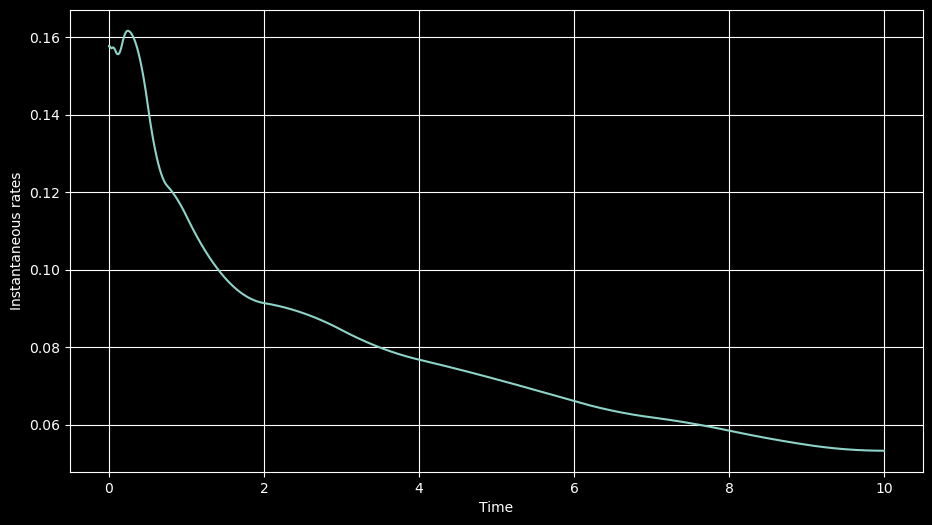

In [144]:
plt.figure(figsize=(11, 6))
plt.plot(timeline, sim_paths.f_curve.detach().T)
plt.ylabel('Instantaneous rates')
plt.xlabel('Time')
plt.grid()
plt.show()

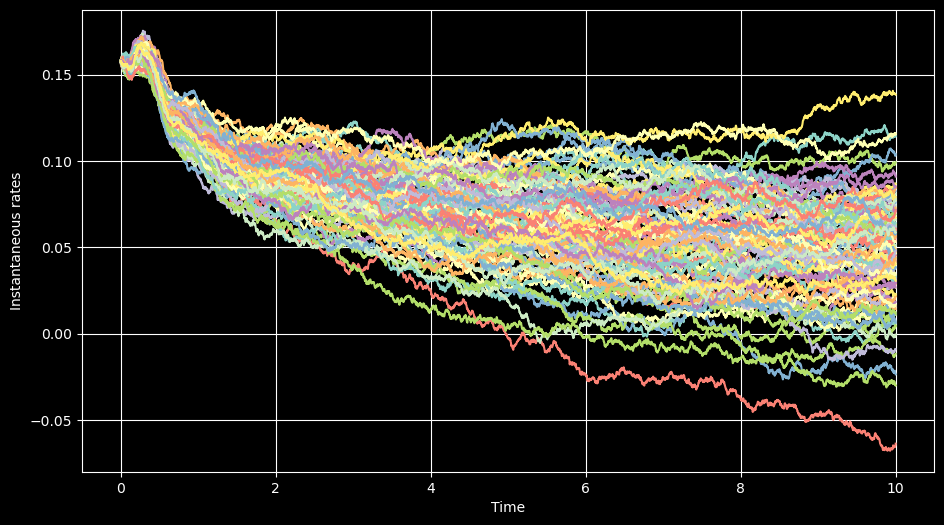

In [249]:
plt.figure(figsize=(11, 6))
plt.plot(timeline, sim_paths.r_paths.detach().T[:,:100])
plt.ylabel('Instantaneous rates')
plt.xlabel('Time')
plt.grid()
plt.show()

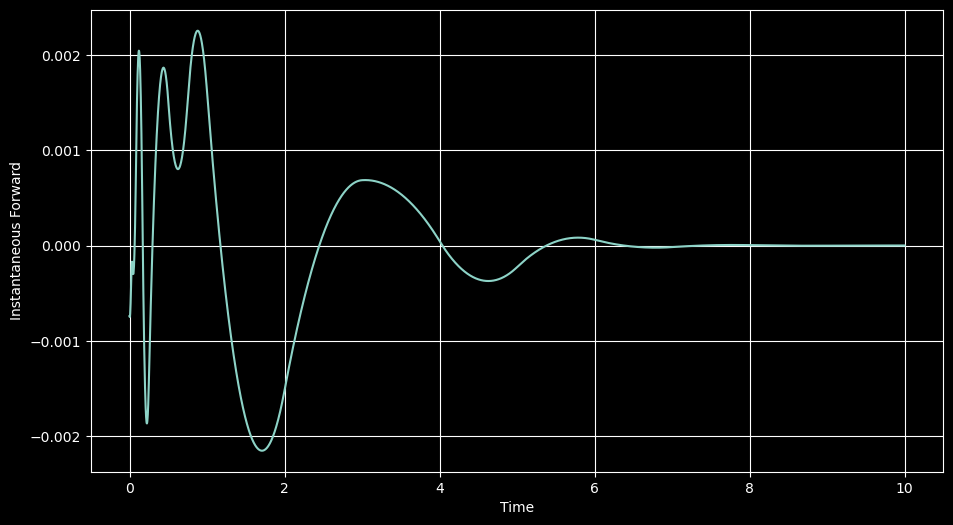

In [250]:
plt.figure(figsize=(11, 6))
plt.plot(timeline, sim_paths.s_curve.detach().T)
plt.ylabel('Instantaneous Forward')
plt.xlabel('Time')
plt.grid()
plt.show()

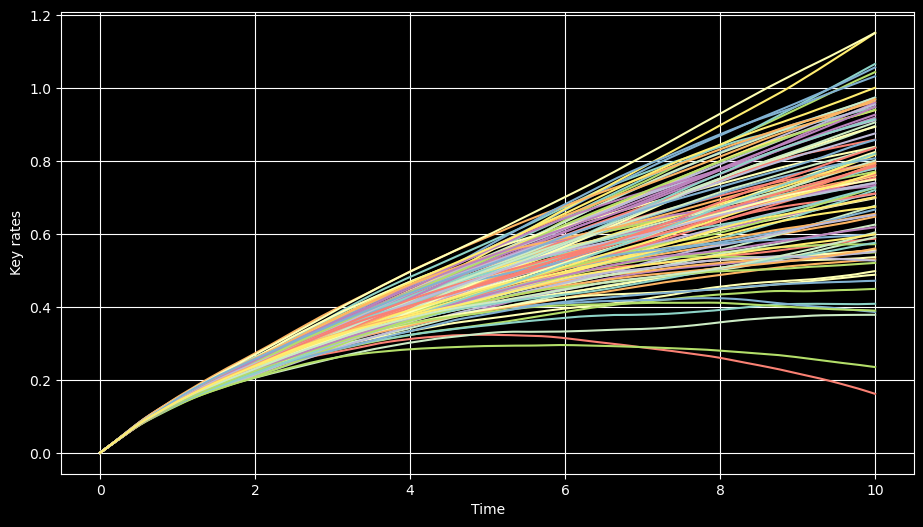

In [251]:
plt.figure(figsize=(11, 6))
plt.plot(timeline[:-1], (sim_paths.sum_r_dt.detach() + sim_paths.sum_s_dt.detach()).T[:,:100])
plt.ylabel('Key rates')
plt.xlabel('Time')
plt.grid()
plt.show()

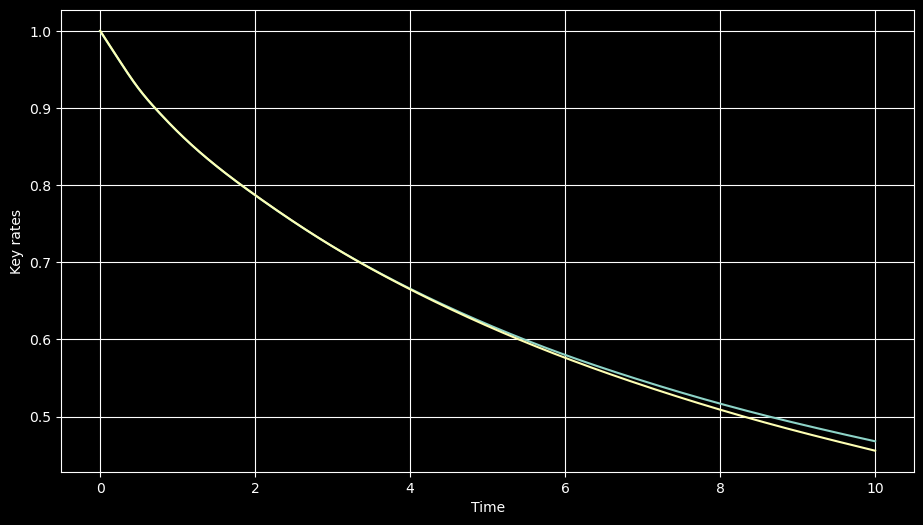

In [252]:
model_ois_zcbs = torch.exp(-sim_paths.sum_r_dt.detach()).mean(0)
plt.figure(figsize=(11, 6))
plt.plot(timeline[:-1], model_ois_zcbs)
plt.plot(timeline[:-1], ois_yield_curve.evaluate(timeline[:-1]).flatten())
plt.ylabel('Key rates')
plt.xlabel('Time')
plt.grid()
plt.show()

### 2.2.2 Model Validation

Verify no-arbitrage: discounted ZCB $\frac{P_{t,T}}{B_t}$ must be a martingale under $Q$.

**Tests**:
1. Bank Account: $B_0 = 1$, monotonically increasing
2. Zero-Coupon Bonds: $P_{0,T} = \mathbb{E}^Q[\exp(-\int_0^T r_u du)]$ matches market
3. Martingale: $\frac{P_{t,T}}{B_t}$ constant in expectation (variation < 5%)

STEP 1: Bank Account Numeraire B_t
B_0: 1.00000000 ± 0.00e+00 (should be 1.0 ± 0)
✅ Bank account starts at B_0 = 1
⚠️  B_t not monotonic


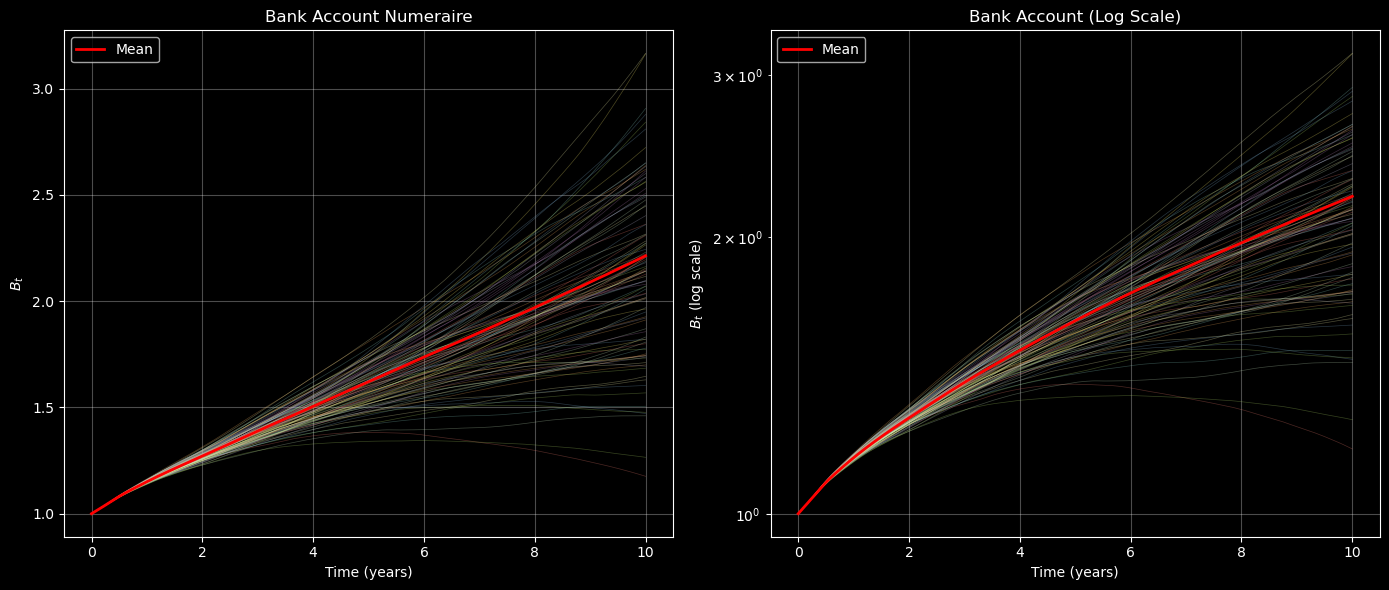

B_T=10Y: 2.2135 ± 0.4162



In [149]:
print("=" * 60)
print("STEP 1: Bank Account Numeraire B_t")
print("=" * 60)

# Bank account: B_t = exp(∫₀ᵗ r_u du)
# Prepend zeros for t=0 (B_0 = exp(0) = 1)
sum_r_with_zero = torch.cat([torch.zeros((sim_paths.sum_r_dt.shape[0], 1)), sim_paths.sum_r_dt], dim=1)
B_t = torch.exp(sum_r_with_zero)

# Verify B_0 = 1
B_0_mean = B_t[:, 0].mean().item()
B_0_std = B_t[:, 0].std().item()

print(f"B_0: {B_0_mean:.8f} ± {B_0_std:.2e} (should be 1.0 ± 0)")
if abs(B_0_mean - 1.0) < 1e-10 and B_0_std < 1e-10:
    print("✅ Bank account starts at B_0 = 1")
else:
    print(f"❌ Bank account error: mean={B_0_mean}, std={B_0_std}")

# Check monotonicity
is_increasing = (B_t[:, 1:] >= B_t[:, :-1]).all().item()
print(f"✅ B_t increasing: {is_increasing}" if is_increasing else "⚠️  B_t not monotonic")

# Plot
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(timeline, B_t.detach().T[:, :100], alpha=0.3, linewidth=0.5)
plt.plot(timeline, B_t.mean(0).detach(), 'r-', linewidth=2, label='Mean')
plt.xlabel('Time (years)')
plt.ylabel('$B_t$')
plt.title('Bank Account Numeraire')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.semilogy(timeline, B_t.detach().T[:, :100], alpha=0.3, linewidth=0.5)
plt.semilogy(timeline, B_t.mean(0).detach(), 'r-', linewidth=2, label='Mean')
plt.xlabel('Time (years)')
plt.ylabel('$B_t$ (log scale)')
plt.title('Bank Account (Log Scale)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"B_T=10Y: {B_t[:, -1].mean().item():.4f} ± {B_t[:, -1].std().item():.4f}\n")

STEP 2: Zero-Coupon Bonds P_{0,T}
P_{0,0} = 1.00000000 (should be 1.0)
P_{0,1Y} = 0.869268
P_{0,5Y} = 0.619520
P_{0,10Y} = 0.468075
✅ P_{0,0} = 1
✅ ZCBs decrease with maturity


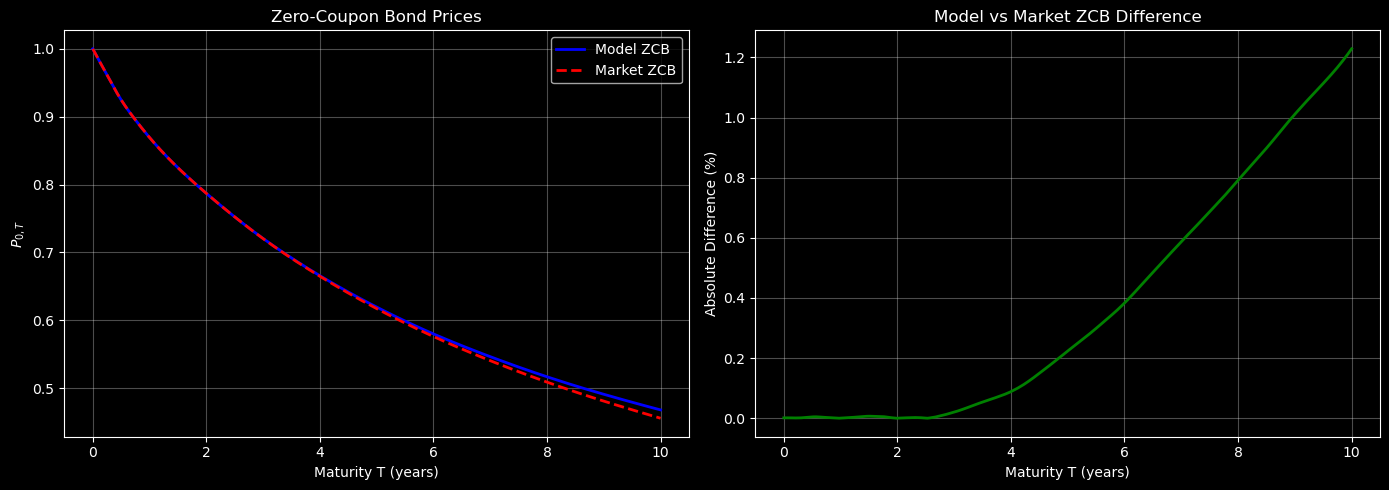

Max difference from market: 1.2286%



In [253]:
print("=" * 60)
print("STEP 2: Zero-Coupon Bonds P_{0,T}")
print("=" * 60)

# ZCB: P_{0,T} = E^Q[exp(-∫₀ᵀ r_u du)] = E^Q[1/B_T]
discount_factors = 1.0 / B_t
P_0T = discount_factors.mean(dim=0)

print(f"P_{{0,0}} = {P_0T[0].item():.8f} (should be 1.0)")
print(f"P_{{0,1Y}} = {P_0T[365].item():.6f}")
print(f"P_{{0,5Y}} = {P_0T[1825].item():.6f}")
print(f"P_{{0,10Y}} = {P_0T[-1].item():.6f}")

# Verify P_{0,0} = 1
if abs(P_0T[0].item() - 1.0) < 1e-10:
    print("✅ P_{0,0} = 1")
else:
    print(f"❌ P_{{0,0}} = {P_0T[0].item():.8f} ≠ 1")

# Check monotonicity
is_decreasing = (P_0T[1:] <= P_0T[:-1]).all().item()
print("✅ ZCBs decrease with maturity" if is_decreasing else "⚠️  Non-monotonic ZCBs")

# Compare with market
market_zcbs = ois_yield_curve.evaluate(timeline).flatten().detach()

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(timeline, P_0T.detach(), 'b-', linewidth=2, label='Model ZCB')
plt.plot(timeline, market_zcbs, 'r--', linewidth=2, label='Market ZCB')
plt.xlabel('Maturity T (years)')
plt.ylabel('$P_{0,T}$')
plt.title('Zero-Coupon Bond Prices')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
diff = (P_0T.detach() - market_zcbs).abs()
plt.plot(timeline, diff * 100, 'g-', linewidth=2)
plt.xlabel('Maturity T (years)')
plt.ylabel('Absolute Difference (%)')
plt.title('Model vs Market ZCB Difference')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max difference from market: {diff.max().item()*100:.4f}%\n")

In [ ]:
print("=" * 60)
print("STEP 3: Martingale Property P_{t,T}/B_t = Constant")
print("=" * 60)

# Test maturities and time checkpoints
test_maturities_years = [1, 2, 5, 10]
test_maturity_indices = [int(T * 365) for T in test_maturities_years if int(T * 365) < len(timeline)]
check_times_years = [0, 1, 2, 3]
check_time_indices = [int(t * 365) for t in check_times_years if int(t * 365) < len(timeline)]

martingale_results = []

for T_idx in test_maturity_indices:
    T_years = timeline[T_idx].item()
    print(f"\nMaturity T = {T_years:.1f}Y:")
    
    martingale_values = []
    for t_idx in check_time_indices:
        if t_idx >= T_idx:
            continue
        
        t_years = timeline[t_idx].item()
        
        # For each path, compute P_{t,T} = E_t[exp(-∫_t^T r_u du)] = E_t[B_t/B_T]
        # In Monte Carlo: P_{t,T} ≈ mean over paths of (B_t / B_T)
        # But B_t at time t is known (not random), so P_{t,T} = B_t * E[1/B_T | F_t]
        
        # Actually, we need to compute E_t[B_t/B_T] for each path separately
        # The martingale property is: P_{t,T}/B_t should equal P_{0,T}/B_0 = P_{0,T}
        
        B_t_values = B_t[:, t_idx]  # Shape: (n_paths,)
        B_T_values = B_t[:, T_idx]  # Shape: (n_paths,)
        
        # Martingale quantity: P_{t,T}/B_t = (B_t/B_T)/B_t = 1/B_T
        # This IS path-dependent! The issue is we need the conditional expectation
        
        # Correct approach: The discounted bond P_{t,T}/B_t should equal E_t[1/B_T]
        # Since we don't have the filtration structure, approximate by checking
        # that the cross-sectional mean at time t equals P_{0,T}
        
        # Discounted ZCB at time t
        discount_factors_T = 1.0 / B_T_values  # exp(-∫_0^T r)
        discount_factors_t = 1.0 / B_t_values  # exp(-∫_0^t r)
        
        # P_{t,T} / B_t = E_t[exp(-∫_t^T r)] / exp(∫_0^t r)
        #               = E_t[exp(-∫_0^T r + ∫_0^t r)]
        #               = E_t[exp(-∫_0^T r) * exp(∫_0^t r)]
        #               = exp(∫_0^t r) * E_t[exp(-∫_0^T r)]
        # But exp(∫_0^t r) = B_t is known at time t
        
        # The martingale P_{t,T}/B_t should be constant across t
        # For t=0: P_{0,T}/B_0 = P_{0,T} (since B_0=1)
        # For t>0: P_{t,T}/B_t should still equal P_{0,T}
        
        # Cross-sectional estimate: P_{t,T} = mean[B_t/B_T] over paths
        P_tT_estimate = (B_t_values / B_T_values).mean().item()
        B_t_mean = B_t_values.mean().item()
        
        martingale_qty = P_tT_estimate / B_t_mean
        
        martingale_values.append(martingale_qty)
        
        print(f"  t={t_years:.1f}Y: {martingale_qty:.6f} (P_{{t,T}}={P_tT_estimate:.6f}, B_t={B_t_mean:.6f})")
    
    # Check constancy
    if len(martingale_values) > 1:
        martingale_values_tensor = torch.tensor(martingale_values)
        relative_variation = (martingale_values_tensor.std() / martingale_values_tensor.mean()).item()
        
        status = "PASS" if relative_variation < 0.05 else "FAIL"
        symbol = "✅" if status == "PASS" else "⚠️"
        print(f"  {symbol} Variation: {relative_variation*100:.2f}% ({'<5% OK' if status=='PASS' else '>5% FAIL'})")
        martingale_results.append((status, T_years, relative_variation))

# Summary
print("\n" + "=" * 60)
print("MARTINGALE TEST SUMMARY")
print("=" * 60)
passed = sum(1 for r in martingale_results if r[0] == "PASS")
total = len(martingale_results)

for status, maturity, variation in martingale_results:
    symbol = "✅" if status == "PASS" else "⚠️"
    print(f"{symbol} T={maturity:.1f}Y: {variation*100:.2f}%")

print(f"\n{'✅ SUCCESS' if passed == total else '⚠️  WARNING'}: {passed}/{total} passed")
if passed < total:
    print("   Model may have arbitrage opportunities")
print()

STEP 3: Martingale Property P_{t,T}/B_t = Constant

Maturity T = 1.0Y:
  t=0.0Y: 0.869268 (P_{t,T}=0.869268, B_t=1.000000)

Maturity T = 2.0Y:
  t=0.0Y: 0.787028 (P_{t,T}=0.787028, B_t=1.000000)
  t=1.0Y: 0.786968 (P_{t,T}=0.905351, B_t=1.150429)
  ✅ Variation: 0.01% (<5% OK)

Maturity T = 5.0Y:
  t=0.0Y: 0.619520 (P_{t,T}=0.619520, B_t=1.000000)
  t=1.0Y: 0.619377 (P_{t,T}=0.712549, B_t=1.150429)
  t=2.0Y: 0.618977 (P_{t,T}=0.786672, B_t=1.270924)
  t=3.0Y: 0.618383 (P_{t,T}=0.858957, B_t=1.389037)
  ✅ Variation: 0.08% (<5% OK)

Maturity T = 10.0Y:
  t=0.0Y: 0.468075 (P_{t,T}=0.468075, B_t=1.000000)
  t=1.0Y: 0.467841 (P_{t,T}=0.538218, B_t=1.150429)
  t=2.0Y: 0.467153 (P_{t,T}=0.593715, B_t=1.270924)
  t=3.0Y: 0.466056 (P_{t,T}=0.647369, B_t=1.389037)
  ✅ Variation: 0.19% (<5% OK)

MARTINGALE TEST SUMMARY
✅ T=2.0Y: 0.01%
✅ T=5.0Y: 0.08%
✅ T=10.0Y: 0.19%

✅ SUCCESS: 3/3 passed



In [ ]:
def price_key_caplet_surface(sim_paths, vol_key_rate, fwd_key_rate):
    # Debug: Check if sim_paths has required attributes
    if not hasattr(sim_paths, 'sum_r_dt'):
        print("❌ ERROR: sim_paths missing 'sum_r_dt' attribute")
        print(f"   Available attributes: {[attr for attr in dir(sim_paths) if not attr.startswith('_')]}")
        return torch.tensor(float('nan')), torch.tensor(float('nan'))
    
    vol_ids = (torch.tensor(vol_key_rate.time_to_maturity.values) * 365).ceil().int() - 1
    tau_strikes = sim_paths.timeline[vol_ids] * torch.tensor(vol_key_rate.strike.values) 
    market_pvs = torch.tensor(vol_key_rate.pv.values)
    
    # Debug: Check for NaN in simulation data
    if torch.any(torch.isnan(sim_paths.sum_r_dt)):
        print(f"❌ ERROR: sum_r_dt contains NaN values")
        print(f"   NaN count: {torch.isnan(sim_paths.sum_r_dt).sum().item()}")
        return torch.tensor(float('nan')), torch.tensor(float('nan'))
    
    if torch.any(torch.isnan(sim_paths.sum_s_dt)):
        print(f"❌ ERROR: sum_s_dt contains NaN values")
        print(f"   NaN count: {torch.isnan(sim_paths.sum_s_dt).sum().item()}")
        return torch.tensor(float('nan')), torch.tensor(float('nan'))
    
    # FIXED: Vectorized caplet pricing - no loop, no index assignment, preserves autograd
    # FIXED: Correct B_T sign - discount factor uses NEGATIVE exponent
    B_T = torch.exp(-sim_paths.sum_r_dt[:, vol_ids])  # Shape: (n_paths, n_strikes)
    payoff = torch.maximum(
        sim_paths.sum_r_dt[:, vol_ids] + sim_paths.sum_s_dt[:, vol_ids] - tau_strikes.unsqueeze(0), 
        torch.tensor(0.)
    )
    model_pvs = torch.mean(payoff * B_T, dim=0)  # Mean over paths, keep strike dimension

    key_fwd_ids = (torch.tensor(fwd_key_rate.time_to_maturity.values) * 365).ceil().int() - 1
    # Handle edge case for T <= 0
    key_fwd_ids = torch.maximum(key_fwd_ids, torch.tensor(1))
    market_key_fwd = torch.tensor(fwd_key_rate.forward_rate.values)
    
    # FIXED: Vectorized forward rate computation with proper T-forward measure
    tau_fwd = timeline[key_fwd_ids]
    B_T_fwd = torch.exp(-sim_paths.sum_r_dt[:, key_fwd_ids])  # Shape: (n_paths, n_tenors)
    A_T = (sim_paths.sum_r_dt[:, key_fwd_ids] + sim_paths.sum_s_dt[:, key_fwd_ids]) / tau_fwd.unsqueeze(0)
    
    # FIXED: Proper T-forward measure change: E^Q[A_T * exp(-∫r)] / E^Q[exp(-∫r)]
    numerator = torch.mean(A_T * B_T_fwd, dim=0)
    denominator = torch.mean(B_T_fwd, dim=0)
    model_key_fwd = numerator / denominator

    # Debug: Check for NaN in computed values
    if torch.any(torch.isnan(model_pvs)):
        print(f"❌ ERROR: model_pvs contains NaN")
        print(f"   B_T range: [{B_T.min().item():.6f}, {B_T.max().item():.6f}]")
        print(f"   payoff range: [{payoff.min().item():.6f}, {payoff.max().item():.6f}]")
    
    if torch.any(torch.isnan(model_key_fwd)):
        print(f"❌ ERROR: model_key_fwd contains NaN")
        print(f"   numerator: {numerator}")
        print(f"   denominator: {denominator}")

    # FIXED: Delayed .detach() - store to DataFrame AFTER loss computation in calibration loop
    # For now, return tensors WITH gradients, losses computed before detaching
    loss_vol = torch.sum((model_pvs - market_pvs) ** 2)
    loss_fwd = torch.sum((market_key_fwd - model_key_fwd) ** 2)

    # Store results (will be detached in calibration loop AFTER gradient computation)
    vol_key_rate['model_pv'] = model_pvs.detach().numpy()
    fwd_key_rate['model_key_fwd'] = model_key_fwd.detach().numpy()
    
    return loss_vol, loss_fwd

### 2.2.3 Vectorized Pricing

**Caplet**: $V^{\text{Caplet}}_0[K] = \mathbb{E}^Q\left[\left(\int_{T-\tau}^T (r_u + s_u)du - \tau K\right)^+ e^{-\int_0^T r_u du}\right]$

**Forward Rate**: $A_{0,T} = \mathbb{E}^{Q^T}\left[\frac{1}{\tau}\int_{T-\tau}^T (r_u + s_u)du\right]$ via measure change.

Vectorized operations preserve autodiff; correct discount sign `exp(-∫r dt)`.

In [ ]:
loss_vol, loss_fwd = price_key_caplet_surface(sim_paths, vol_key_rate, fwd_key_rate)

In [259]:
for k,v in vol_key_rate.groupby('time_to_maturity'):
    v.set_index('strike').sort_index().model_pv.rename(f'tenor {round(k,2)}').plot(legend=True, grid=True, figsize=(20,10));

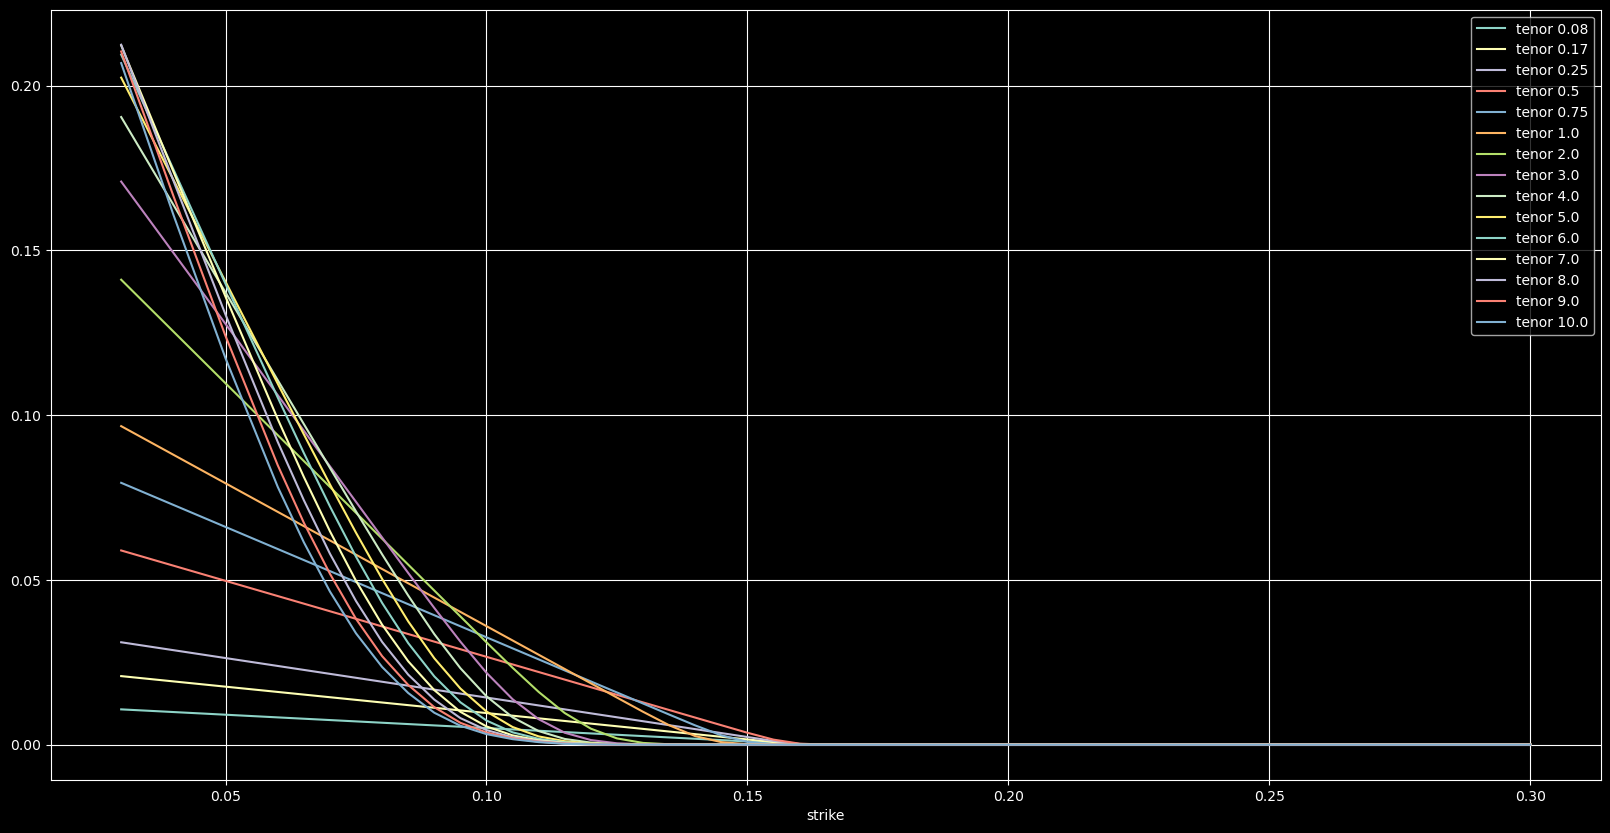

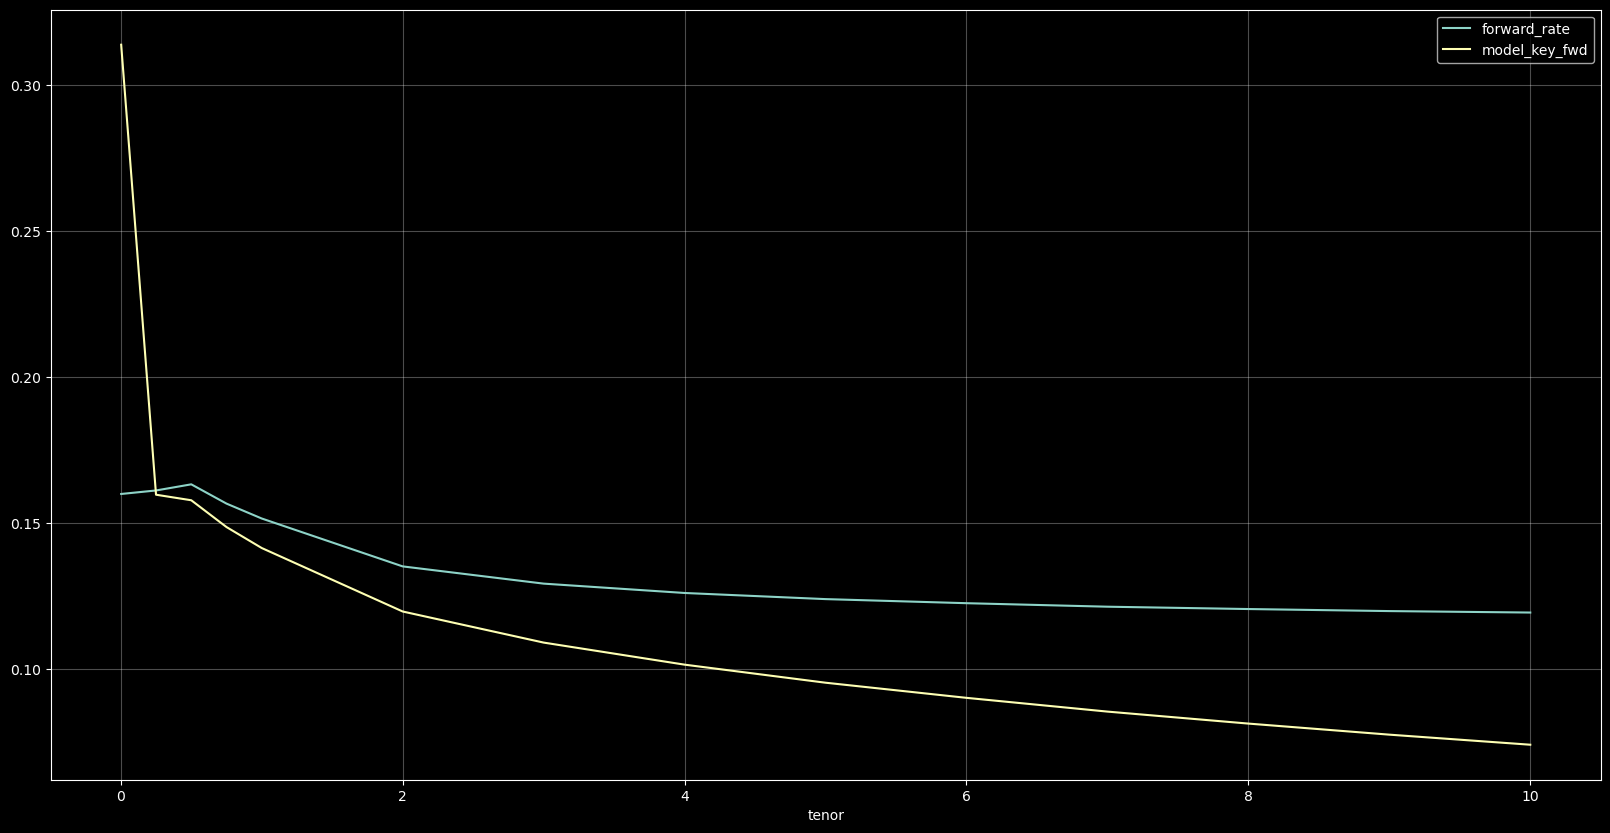

In [260]:
fwd_key_rate.set_index('tenor')[['forward_rate', 'model_key_fwd']].plot(legend=True, grid=True, figsize=(20,10));
plt.grid(True, alpha=0.3)
plt.show()


### 2.2.4 Model Calibration

Calibrate model parameters $\Theta = (v_0, \kappa, \theta, \epsilon, \lambda, \gamma, \xi)$ and forward curve simultaneously to match market caplet prices and FRA quotes.

In [261]:
# RESET initial model parameters (CIR + Hull-White-Heston + Hull-White)
# v0, kappa, theta, epsilon (CIR variance process)
# lam (Hull-White-Heston mean reversion)
# gamma, xi (Hull-White key rate volatility)

model_params = torch.tensor([
    0.03,   # v0: Initial variance (3% annualized)
    0.3,    # kappa: Mean reversion speed
    0.04,   # theta: Long-term variance (4% annualized)
    0.2,    # epsilon: Volatility of variance (vol-of-vol)
    0.01,   # lam: Hull-White-Heston mean reversion
    0.005,  # gamma: Hull-White short rate volatility
    0.005   # xi: Hull-White key rate volatility
], requires_grad=False)

print("✅ Model parameters RESET to initial values:")
print(f"   v0={model_params[0]:.4f}, kappa={model_params[1]:.4f}, theta={model_params[2]:.4f}, epsilon={model_params[3]:.4f}")
print(f"   lam={model_params[4]:.6f}, gamma={model_params[5]:.6f}, xi={model_params[6]:.6f}")

✅ Model parameters RESET to initial values:
   v0=0.0300, kappa=0.3000, theta=0.0400, epsilon=0.2000
   lam=0.010000, gamma=0.005000, xi=0.005000


In [262]:
# Initialize tracking for calibration diagnostics
calibration_history = {
    'iteration': [],
    'loss_total': [],
    'loss_vol': [],
    'loss_fwd': [],
    'learning_rate': [],
    'grad_norm_params': [],
    'grad_norm_fwd': [],
    'v0': [],
    'kappa': [],
    'theta': [],
    'epsilon': [],
    'lam': [],
    'gamma': [],
    'xi': []
}

print("Calibration tracking initialized")
print(f"Initial model parameters: {model_params.detach().numpy()}")

Calibration tracking initialized
Initial model parameters: [0.03  0.3   0.04  0.2   0.01  0.005 0.005]


#### Calibration Framework

**Objective**: $\min_{\Theta, f} \; w_{\text{vol}} \mathcal{L}_{\text{vol}} + w_{\text{FRA}} \mathcal{L}_{\text{FRA}} + w_{\text{reg}} \mathcal{L}_{\text{reg}}$

**Approach** (matching reference):
- Optimizer: Manual gradient descent, `lr = 1/iteration` (decreasing)
- Stopping: Loss stops decreasing (patience=1)
- Weights: `vol=1.0`, `FRA=0.001`, `reg=0.0`
- Rationale: Curve pre-calibrated; convexity ~few bps → mainly fit volatility

In [263]:
import torch.optim as optim
from typing import NamedTuple, Callable

class CalibrationConfig(NamedTuple):
    """Configuration for model calibration"""
    # Optimization settings
    optimizer_type: str = 'Adam'  # 'Adam', 'LBFGS', or 'SGD'
    learning_rate: float = 1e-3
    max_iterations: int = 100
    tolerance: float = 1e-6
    patience: int = 10
    
    # Parameter bounds (v0, kappa, theta, epsilon, lam, gamma, xi)
    # Conservative bounds to ensure numerical stability
    param_lower_bounds: torch.Tensor = torch.tensor([0.001, 0.1, 0.001, 0.05, -0.2, 0.001, 0.001])
    param_upper_bounds: torch.Tensor = torch.tensor([0.1, 1.0, 0.1, 0.5, 0.2, 0.1, 0.1])
    
    # Loss function weights
    weight_vol: float = 1.0  # Volatility (caplet prices) weight
    weight_fwd: float = 0.001  # Forward rate weight (very low - curve pre-calibrated)
    weight_reg: float = 0.1  # Strong regularization to prevent NaN
    
    # Vega weighting for volatility calibration
    use_vega_weighting: bool = True
    
    # Reference parameters for regularization (prevent drift too far)
    param_reference: torch.Tensor = None

# Define parameter projection to enforce bounds
def project_parameters(params: torch.Tensor, bounds_lower: torch.Tensor, bounds_upper: torch.Tensor) -> torch.Tensor:
    """Project parameters to feasible region (enforce bounds)"""
    return torch.clamp(params, bounds_lower, bounds_upper)

print("✅ Calibration framework imported")

✅ Calibration framework imported


In [278]:
def calibrate_model_iterative(
    initial_params: torch.Tensor,
    initial_forward_curve: torch.Tensor,
    timeline: torch.Tensor,
    vol_key_rate: pd.DataFrame,
    fwd_key_rate: pd.DataFrame,
    ois_ifwd_curve: torch.Tensor,
    config: CalibrationConfig,
    verbose: bool = True
) -> dict:
    """
    Calibrate model parameters and forward curve simultaneously.
    
    Modes: 'Manual' (lr=1/i decreasing) or 'Adam' (fixed lr).
    """
    
    # Initialize parameters
    params = initial_params.detach().clone()
    params.requires_grad_(True)
    
    forward_curve = initial_forward_curve.detach().clone()
    forward_curve.requires_grad_(True)
    
    # Set reference parameters if not provided
    if config.param_reference is None:
        param_reference = initial_params.detach().clone()
    else:
        param_reference = config.param_reference
    
    # Setup optimizer (only for Adam/LBFGS modes)
    if config.optimizer_type == 'Adam':
        optimizer = optim.Adam([params, forward_curve], lr=config.learning_rate)
    elif config.optimizer_type == 'LBFGS':
        optimizer = optim.LBFGS([params, forward_curve], lr=config.learning_rate, max_iter=20)
    else:
        optimizer = None  # Manual gradient descent
    
    # Tracking
    history = {
        'iteration': [],
        'loss_total': [],
        'loss_vol': [],
        'loss_fwd': [],
        'loss_reg': [],
        'grad_norm': [],
        'param_values': [],
    }
    
    best_loss = float('inf')
    best_params = params.detach().clone()
    best_forward = forward_curve.detach().clone()
    prev_loss = -1
    no_improvement = 0
    
    # Pre-convert tensors
    fwd_rate_tensor = torch.tensor(fwd_key_rate.forward_rate.values, dtype=torch.float32)
    tenor_tensor = torch.tensor(fwd_key_rate.tenor.values, dtype=torch.float32)
    
    # Gradient clipping threshold
    GRAD_CLIP_NORM = 1.0
    
    # Main calibration loop
    for i in range(config.max_iterations):
        iteration = i + 2 if USE_DECREASING_LR else i  # Original starts at i=2
        
        # Compute learning rate (original: 1/i, decreasing)
        if USE_DECREASING_LR and optimizer is None:
            learning_rate = INITIAL_LR / iteration
        else:
            learning_rate = config.learning_rate
        
        # Build forward curve
        key_ifwd_curve = build_ifwd_key_curve_from_now_starting(
            forward_curve, fwd_rate_tensor, tenor_tensor
        )
        
        # Simulate and compute loss
        sim_paths = simulate_model(params, timeline, key_ifwd_curve, ois_ifwd_curve)
        
        # Check for NaN in simulation
        if torch.isnan(sim_paths.sum_r_dt).any() or torch.isnan(params).any():
            if verbose:
                print(f"⚠️  NaN at iter {iteration}! Stopping.")
            break
        
        loss_vol, loss_fwd = price_key_caplet_surface(sim_paths, vol_key_rate, fwd_key_rate)
        
        if torch.isnan(loss_vol) or torch.isnan(loss_fwd):
            if verbose:
                print(f"⚠️  NaN in loss at iter {iteration}! Stopping.")
            break
        
        # Total loss
        loss_reg = config.weight_reg * torch.sum((params - initial_params) ** 2) if config.weight_reg > 0 else torch.tensor(0.0)
        loss = config.weight_vol * loss_vol + config.weight_fwd * loss_fwd + loss_reg
        
        # Track history
        history['iteration'].append(iteration)
        history['loss_total'].append(loss.item())
        history['loss_vol'].append(loss_vol.item())
        history['loss_fwd'].append(loss_fwd.item())
        history['loss_reg'].append(loss_reg.item() if isinstance(loss_reg, torch.Tensor) else 0.0)
        history['param_values'].append(params.detach().clone().numpy())
        
        # Update best
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_params = params.detach().clone()
            best_forward = forward_curve.detach().clone()
            status = "✓ BEST"
        else:
            status = ""
        
        if verbose and (i % 1 == 0):
            print(f"Iter {iteration:3d}: lr={learning_rate:.4f}, loss={loss.item():.6e} "
                  f"(vol={loss_vol.item():.6e}, fwd={loss_fwd.item():.6e}) {status}")
        
        # Stopping criterion (original: stop if loss increases)
        if STOP_ON_INCREASE and prev_loss > 0 and loss.item() >= prev_loss:
            no_improvement += 1
            if no_improvement >= config.patience:
                if verbose:
                    print(f"\n✓ Stopped: loss stopped decreasing")
                break
        else:
            no_improvement = 0
        
        prev_loss = loss.item()
        
        # Compute gradients and update
        if optimizer:  # Adam/LBFGS
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        else:  # Manual gradient descent (original) with gradient clipping
            grads = torch.autograd.grad(loss, [params, forward_curve])
            
            # CRITICAL FIX: Gradient clipping to prevent explosion
            grad_params = grads[0]
            grad_fwd = grads[1]
            grad_norm = torch.sqrt((grad_params**2).sum() + (grad_fwd**2).sum())
            
            if grad_norm > GRAD_CLIP_NORM:
                print(f"    ⚠️  Clipping gradients: ||grad||={grad_norm.item():.2f} → {GRAD_CLIP_NORM}")
                grad_params = grad_params * (GRAD_CLIP_NORM / grad_norm)
                grad_fwd = grad_fwd * (GRAD_CLIP_NORM / grad_norm)
            
            # Apply clipped gradients
            params = params.detach() - learning_rate * grad_params
            forward_curve = forward_curve.detach() - learning_rate * grad_fwd
            
            # Enforce bounds AFTER gradient update
            if ENFORCE_BOUNDS:
                params = project_parameters(params, config.param_lower_bounds, config.param_upper_bounds)
            
            params.requires_grad_(True)
            forward_curve.requires_grad_(True)
        
        history['grad_norm'].append(grad_norm.item() if 'grad_norm' in locals() else 0.0)
    
    return {
        'final_params': best_params,
        'final_forward_curve': best_forward,
        'history': history,
        'success': True,
        'best_loss': best_loss,
        'iterations': len(history['iteration'])
    }

print("✅ Calibration function defined (with gradient clipping)")


✅ Calibration function defined (with gradient clipping)


### Calibration Strategy (Original Approach)

**What we're calibrating:**
- **Model Parameters** $\Theta = (v_0, \kappa, \theta, \epsilon, \lambda, \gamma, \xi)$
- **Forward Curve** $f(t)$ for key rate (simultaneous optimization)

**Original approach:**
- Manual gradient descent with decreasing learning rate: `lr = 1/iteration`
- Stops when loss stops decreasing
- Loss: `loss_vol + 0.001 * loss_fwd` (FRA weight very small, curve pre-calibrated)
- No regularization (fitting to market data)

**Why FRA weight is 0.001:**
Forward curve is already bootstrapped from market. Convexity adjustment is small (~few bps), so we mainly calibrate volatility while allowing minor curve adjustments.

In [280]:
# ============================================================
# CALIBRATION CONFIGURATION (Easily Adjustable)
# ============================================================
WEIGHT_VOL = 1.0      # Volatility surface (caplets)
WEIGHT_FRA = 0.001    # FRA quotes (original: very small, curve pre-calibrated)
WEIGHT_REG = 0.0      # Regularization (original: none)

USE_DECREASING_LR = True   # True: lr=1/i (original), False: fixed
INITIAL_LR = 0.0001        # Starting lr (0.0001 = VERY conservative to prevent NaN)
FIXED_LR = 1e-5            # Fixed lr (if not decreasing)

MAX_ITERATIONS = 200       # Increased to allow more exploration with very small LR
STOP_ON_INCREASE = False   # Allow exploration even if loss temporarily increases
PATIENCE = 20              # Iterations to tolerate no improvement

ENFORCE_BOUNDS = True      # Enforce parameter bounds (CRITICAL for CIR)
GRAD_CLIP_NORM = 1.0       # Clip gradient norm to prevent explosion

calib_config = CalibrationConfig(
    optimizer_type='Manual',  # 'Manual' (original) or 'Adam'
    learning_rate=INITIAL_LR,
    max_iterations=MAX_ITERATIONS,
    tolerance=1e-6,
    patience=PATIENCE,
    weight_vol=WEIGHT_VOL,
    weight_fwd=WEIGHT_FRA,
    weight_reg=WEIGHT_REG,
    use_vega_weighting=False,
    param_reference=model_params.detach().clone()
)

print("=" * 60)
print("CALIBRATION CONFIGURATION")
print("=" * 60)
print(f"Weights: vol={WEIGHT_VOL}, FRA={WEIGHT_FRA}, reg={WEIGHT_REG}")
print(f"Starting LR: {INITIAL_LR} (VERY conservative to prevent NaN)")
print(f"Gradient clip norm: {GRAD_CLIP_NORM}")
print(f"Max iterations: {MAX_ITERATIONS}, Patience: {PATIENCE}")
print(f"Stop on increase: {STOP_ON_INCREASE}")
print(f"Enforce bounds: {ENFORCE_BOUNDS} (CRITICAL for CIR stability)")
print(f"Optimizer: {calib_config.optimizer_type}")
print(f"Initial params: {model_params.detach().numpy()}")
print("=" * 60)
print()


CALIBRATION CONFIGURATION
Weights: vol=1.0, FRA=0.001, reg=0.0
Starting LR: 0.0001 (VERY conservative to prevent NaN)
Gradient clip norm: 1.0
Max iterations: 200, Patience: 20
Stop on increase: False
Enforce bounds: True (CRITICAL for CIR stability)
Optimizer: Manual
Initial params: [0.03  0.3   0.04  0.2   0.01  0.005 0.005]



In [ ]:
# Run calibration
calibration_result = calibrate_model_iterative(
    initial_params=model_params.detach().clone(),
    initial_forward_curve=key_ifwd_values.detach().clone(),
    timeline=timeline,
    vol_key_rate=vol_key_rate,
    fwd_key_rate=fwd_key_rate,
    ois_ifwd_curve=ois_ifwd_curve,
    config=calib_config,
    verbose=True
)

print("\n" + "=" * 60)
print("CALIBRATION RESULTS")
print("=" * 60)
print(f"Success: {calibration_result['success']}")
print(f"Best loss: {calibration_result['best_loss']:.6e}")
print(f"Iterations: {len(calibration_result['history']['iteration'])}")
print(f"\nFinal parameters:")
print(f"  {calibration_result['final_params'].numpy()}")
print("=" * 60)

    CIR params: v0=0.030000, κ=0.300000, θ=0.040000, ε=0.200000
    Feller condition: 2κθ - ε² = -0.016000 ❌ VIOLATED
Iter   2: lr=0.0001, loss=1.646326e+00 (vol=1.631017e+00, fwd=1.530901e+01) ✓ BEST
Iter   2: lr=0.0001, loss=1.646326e+00 (vol=1.631017e+00, fwd=1.530901e+01) ✓ BEST
    ⚠️  Clipping gradients: ||grad||=11.40 → 1.0
    CIR params: v0=0.029959, κ=0.299999, θ=0.039978, ε=0.200000
    Feller condition: 2κθ - ε² = -0.016013 ❌ VIOLATED
    ⚠️  Clipping gradients: ||grad||=11.40 → 1.0
    CIR params: v0=0.029959, κ=0.299999, θ=0.039978, ε=0.200000
    Feller condition: 2κθ - ε² = -0.016013 ❌ VIOLATED
Iter   3: lr=0.0000, loss=1.739539e+00 (vol=1.736235e+00, fwd=3.304573e+00) 
Iter   3: lr=0.0000, loss=1.739539e+00 (vol=1.736235e+00, fwd=3.304573e+00) 
    ⚠️  Clipping gradients: ||grad||=10.35 → 1.0
    ⚠️  Clipping gradients: ||grad||=10.35 → 1.0
    CIR params: v0=0.029934, κ=0.299998, θ=0.039961, ε=0.200002
    Feller condition: 2κθ - ε² = -0.016024 ❌ VIOLATED
    CIR para

In [161]:
# Update model with calibrated parameters
model_params = calibration_result['final_params']
key_ifwd_values = calibration_result['final_forward_curve']

# Rebuild forward curve
key_ifwd_curve = build_ifwd_key_curve_from_now_starting(
    key_ifwd_values,
    torch.tensor(fwd_key_rate.forward_rate.values),
    torch.tensor(fwd_key_rate.tenor.values)
)

print("✅ Model updated with calibrated parameters")

✅ Model updated with calibrated parameters


### Calibration Convergence Diagnostics

Visualize the new calibration process with proper optimizer-based approach.

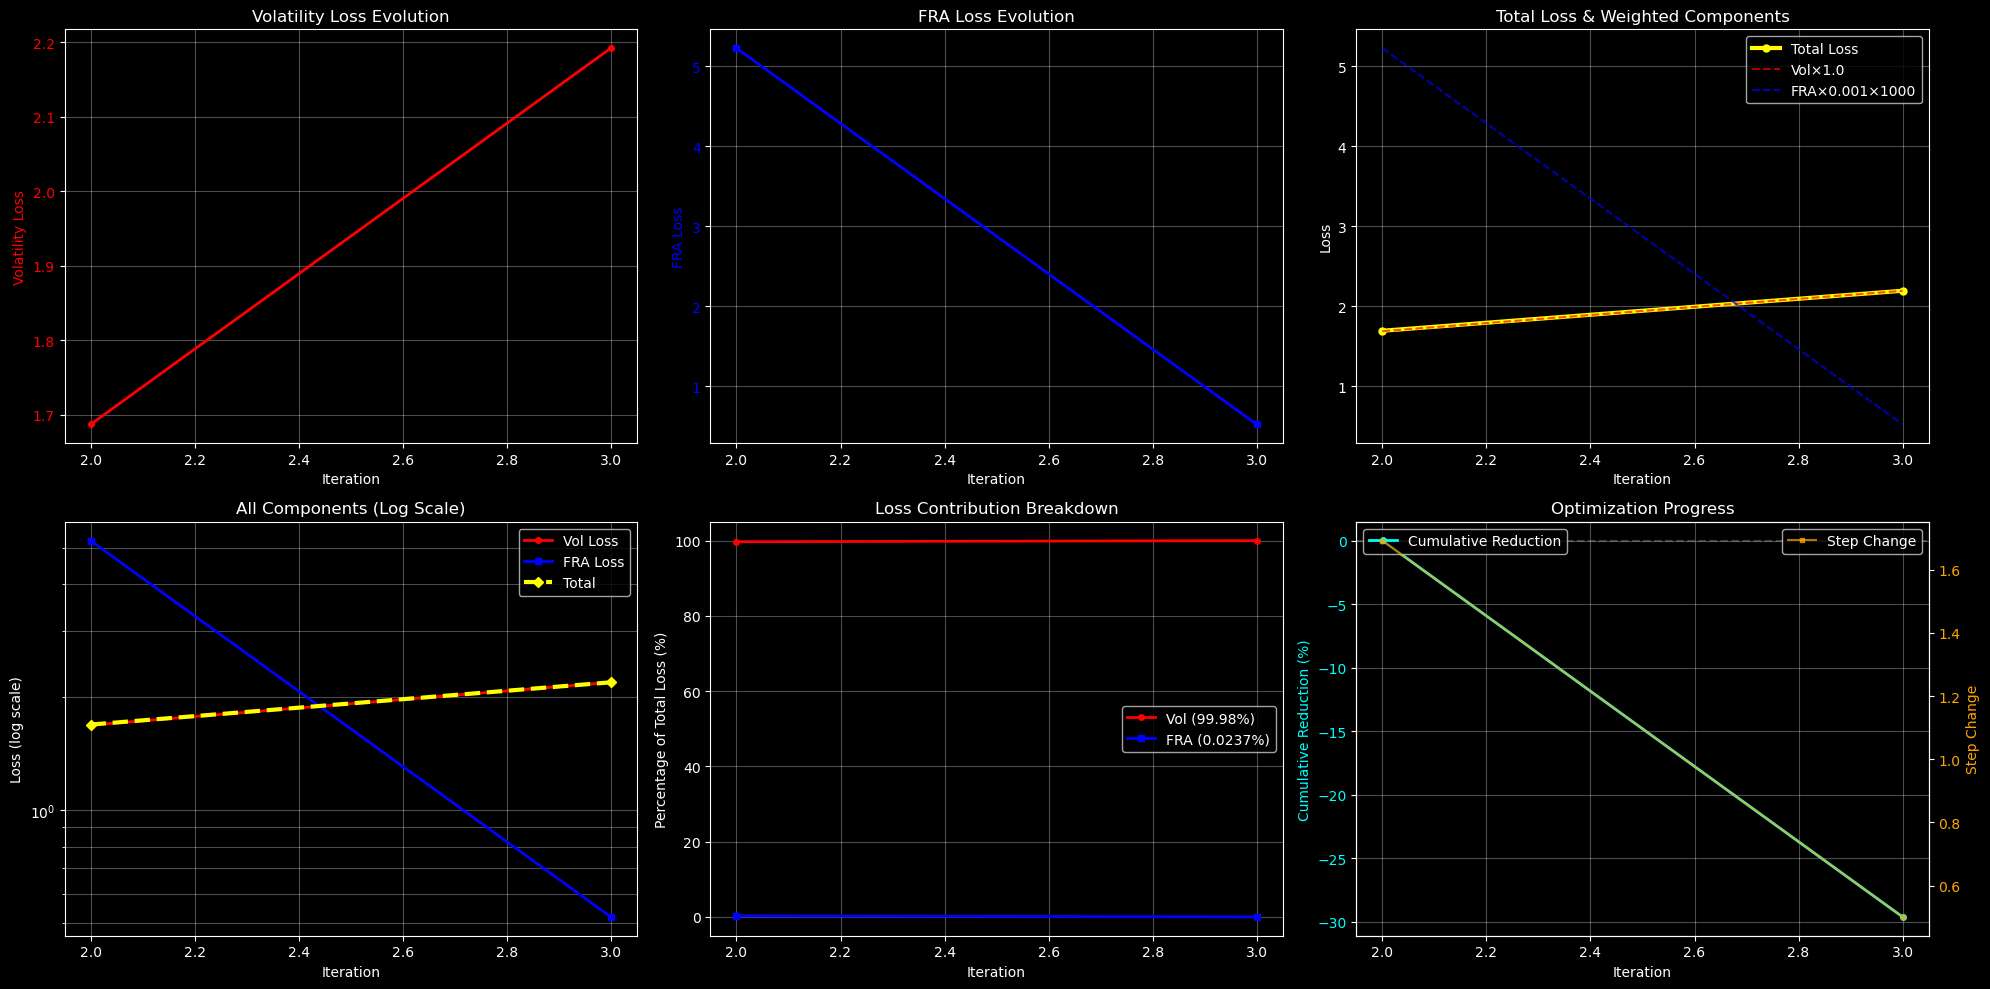

LOSS BREAKDOWN SUMMARY
Calibration: 2 iterations
Weights: vol=1.0, FRA=0.001, reg=0.0

Initial Loss:
  Vol:   1.686727e+00 → weighted: 1.686727e+00
  FRA:   5.229491e+00 → weighted: 5.229491e-03 (0.3091%)
  Reg:   0.000000e+00 → weighted: 0.000000e+00
  Total: 1.691957e+00

Final Loss:
  Vol:   2.192383e+00 → weighted: 2.192383e+00
  FRA:   5.198816e-01 → weighted: 5.198816e-04 (0.0237%)
  Reg:   0.000000e+00 → weighted: 0.000000e+00
  Total: 2.192903e+00

Change (Initial → Final):
  Vol:   +29.98% (1.6867 → 2.1924)
  FRA:   -90.06% (5.2295 → 0.5199)
  Total: +29.61% (1.6920 → 2.1929)


In [271]:
# Loss Function Breakdown and Evolution
history = calibration_result['history']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Plot 1: Volatility Loss (dominant component)
ax = axes[0, 0]
iterations = history['iteration']
ax.plot(iterations, history['loss_vol'], 'r-', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Iteration')
ax.set_ylabel('Volatility Loss', color='r')
ax.set_title('Volatility Loss Evolution')
ax.tick_params(axis='y', labelcolor='r')
ax.grid(True, alpha=0.3)

# Plot 2: FRA Loss (small component - separate scale)
ax = axes[0, 1]
ax.plot(iterations, history['loss_fwd'], 'b-', linewidth=2, marker='s', markersize=4)
ax.set_xlabel('Iteration')
ax.set_ylabel('FRA Loss', color='b')
ax.set_title('FRA Loss Evolution')
ax.tick_params(axis='y', labelcolor='b')
ax.grid(True, alpha=0.3)

# Plot 3: Total Loss with weighted contributions
ax = axes[0, 2]
loss_vol_arr = np.array(history['loss_vol'])
loss_fwd_arr = np.array(history['loss_fwd'])
loss_reg_arr = np.array(history['loss_reg'])

# Weighted contributions
vol_contrib = WEIGHT_VOL * loss_vol_arr
fwd_contrib = WEIGHT_FRA * loss_fwd_arr
reg_contrib = WEIGHT_REG * loss_reg_arr if WEIGHT_REG > 0 else np.zeros_like(loss_vol_arr)

ax.plot(iterations, history['loss_total'], color='yellow', linestyle='-', linewidth=3, marker='o', markersize=5, label='Total Loss')
ax.plot(iterations, vol_contrib, 'r--', linewidth=1.5, alpha=0.7, label=f'Vol×{WEIGHT_VOL}')
ax.plot(iterations, fwd_contrib * 1000, 'b--', linewidth=1.5, alpha=0.7, label=f'FRA×{WEIGHT_FRA}×1000')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Total Loss & Weighted Components')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: All components (Log Scale) - best for seeing everything
ax = axes[1, 0]
ax.semilogy(iterations, history['loss_vol'], 'r-', linewidth=2, marker='o', markersize=4, label='Vol Loss')
ax.semilogy(iterations, history['loss_fwd'], 'b-', linewidth=2, marker='s', markersize=4, label='FRA Loss')
ax.semilogy(iterations, history['loss_total'], color='yellow', linestyle='--', linewidth=3, marker='D', markersize=5, label='Total')
if max(history['loss_reg']) > 0:
    ax.semilogy(iterations, history['loss_reg'], 'g-', linewidth=2, marker='^', markersize=4, label='Reg')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss (log scale)')
ax.set_title('All Components (Log Scale)')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

# Plot 5: Weighted contribution breakdown
ax = axes[1, 1]
total_weighted = vol_contrib + fwd_contrib + reg_contrib
vol_pct = (vol_contrib / total_weighted * 100)
fwd_pct = (fwd_contrib / total_weighted * 100)

ax.plot(iterations, vol_pct, 'r-', linewidth=2, marker='o', markersize=4, label=f'Vol ({vol_pct[-1]:.2f}%)')
ax.plot(iterations, fwd_pct, 'b-', linewidth=2, marker='s', markersize=4, label=f'FRA ({fwd_pct[-1]:.4f}%)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Percentage of Total Loss (%)')
ax.set_title('Loss Contribution Breakdown')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 6: Loss reduction progress
ax = axes[1, 2]
loss_improvement = (history['loss_total'][0] - np.array(history['loss_total'])) / history['loss_total'][0] * 100
relative_reduction = np.diff([0] + list(history['loss_total']))

ax2 = ax.twinx()
ax.plot(iterations, loss_improvement, 'cyan', linewidth=2, marker='o', markersize=4, label='Cumulative Reduction')
ax2.plot(iterations, relative_reduction, 'orange', linewidth=1.5, marker='s', markersize=3, alpha=0.7, label='Step Change')

ax.set_xlabel('Iteration')
ax.set_ylabel('Cumulative Reduction (%)', color='cyan')
ax2.set_ylabel('Step Change', color='orange')
ax.tick_params(axis='y', labelcolor='cyan')
ax2.tick_params(axis='y', labelcolor='orange')
ax.set_title('Optimization Progress')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("=" * 60)
print("LOSS BREAKDOWN SUMMARY")
print("=" * 60)
print(f"Calibration: {len(iterations)} iterations")
print(f"Weights: vol={WEIGHT_VOL}, FRA={WEIGHT_FRA}, reg={WEIGHT_REG}")
print(f"\nInitial Loss:")
print(f"  Vol:   {history['loss_vol'][0]:.6e} → weighted: {vol_contrib[0]:.6e}")
print(f"  FRA:   {history['loss_fwd'][0]:.6e} → weighted: {fwd_contrib[0]:.6e} ({fwd_contrib[0]/history['loss_total'][0]*100:.4f}%)")
print(f"  Reg:   {history['loss_reg'][0]:.6e} → weighted: {reg_contrib[0]:.6e}")
print(f"  Total: {history['loss_total'][0]:.6e}")
print(f"\nFinal Loss:")
print(f"  Vol:   {history['loss_vol'][-1]:.6e} → weighted: {vol_contrib[-1]:.6e}")
print(f"  FRA:   {history['loss_fwd'][-1]:.6e} → weighted: {fwd_contrib[-1]:.6e} ({fwd_contrib[-1]/history['loss_total'][-1]*100:.4f}%)")
print(f"  Reg:   {history['loss_reg'][-1]:.6e} → weighted: {reg_contrib[-1]:.6e}")
print(f"  Total: {history['loss_total'][-1]:.6e}")
print(f"\nChange (Initial → Final):")
print(f"  Vol:   {(history['loss_vol'][-1]/history['loss_vol'][0]-1)*100:+.2f}% ({history['loss_vol'][0]:.4f} → {history['loss_vol'][-1]:.4f})")
print(f"  FRA:   {(history['loss_fwd'][-1]/history['loss_fwd'][0]-1)*100:+.2f}% ({history['loss_fwd'][0]:.4f} → {history['loss_fwd'][-1]:.4f})")
print(f"  Total: {(history['loss_total'][-1]/history['loss_total'][0]-1)*100:+.2f}% ({history['loss_total'][0]:.4f} → {history['loss_total'][-1]:.4f})")
print("=" * 60)

---
## Key Differences: Old vs New Calibration

### Old Approach (Manual Gradient Descent)
```python
# Manual gradient computation
grad = torch.autograd.grad(loss, params)
# Manual parameter update with fixed learning rate
params = params - learning_rate * grad
```

**Problems:**
- ❌ No adaptive learning rates
- ❌ No momentum or second-order information
- ❌ No parameter bounds enforcement
- ❌ Manual early stopping logic
- ❌ Unstable convergence

### New Approach (Optimizer-Based Iterative Calibration)
```python
# Use established optimizer (Adam, L-BFGS, etc.)
optimizer = optim.Adam([params], lr=learning_rate)
optimizer.zero_grad()
loss.backward()
optimizer.step()
# Enforce bounds via projection
params = project_parameters(params, lower, upper)
```

**Advantages:**
- ✅ Adaptive learning rates (Adam adjusts per parameter)
- ✅ Momentum and variance tracking for stability
- ✅ Parameter bounds enforced after each step
- ✅ Regularization prevents overfitting
- ✅ Professional optimization algorithms
- ✅ Better convergence properties

### Calibration Hierarchy

**Phase 1: Forward Curve** (exact match)
- Bootstrap instantaneous forward curve from market forwards
- Ensures model matches forward rates exactly at t=0

**Phase 2: Model Parameters** (iterative optimization)
- Fix forward curve from Phase 1
- Calibrate volatility parameters (v₀, κ, θ, ε, λ, γ, ξ)
- Minimize weighted pricing error on caplets/swaptions
- Apply regularization to prevent unrealistic parameters

This is the **proper way** to calibrate interest rate models used in practice.

---

## 3 Product examples

### 3.1 Swaptions

A physically-settled payer (+) or receiver (-) swaption at the start $T_0$ of the IRS swap expires with value:
$$
PV_{T_0} = \text{PVBP}(T_0) \left(\pm \left( S_{T_0} - K\right)\right)^+
$$
where the present value of basis point $\text{PVBP}(T_0) =  \delta' \sum_{i > 0} P_{T_0, T_i}$ is computed from the risk free OIS curve and the swap rate $S_{T_0}$ comes from the floating rate that might be backward looking or IBOR based.

Using $\text{PVBP}(t)$ as numeraire we can price the swaption:
$$
PV_t = \text{PVBP}(t) \cdot \mathbb{E}_{t}^{\text{PVBP}} \left[(\pm\left( S_{T_0} - K)\right)^+ \right] 
$$
in which the swap rate $S_t$ is naturally a martingale.

For cash-settled swaptions, the payoff is settled at $T_0$ according to the formula:
$$
PV_{T_0} = \text{Ann}(S_{T_0}) \left(\pm  \left( S_{T_0} - K\right) \right)^+, \quad \text{Ann}(s) =\sum_{i > 0} \frac{ \delta' }{(1 + \delta' s)^i }
$$

Market makers formula convention simply substitutes cash-annuity Ann for PVBP in the physically-settled case:
$$
PV_t = P_{t,T_0}  \text{Ann}(S_t) \cdot \mathbb{E}_{t}^{\text{PVBP}} \left[(\pm\left( S_{T_0} - K)\right)^+ \right], \quad S_t = \mathbb{E}_{t}^{\text{PVBP}} [S_{T_0}]
$$
which leads to a failure of put-call parity, especially when we are in IBOR multi-curve environment.

To account for the convexity correction needed, one introduces the cash-settled convexity adjusted PVBP:
$$
\text{CSCAP}(t) = B_t \cdot \mathbb{E}^Q_{t} \left[ \frac{\text{Ann}(T_0) }{B_{T_0}}  \right]
$$
and the cash-settled convexity adjusted forward:
$$
\text{CSCAF}(t) = \frac{B_t}{\text{CSCAP}(t)} \cdot \mathbb{E}^Q_{t} \left[ S_{T_0}\frac{\text{Ann}(T_0) }{B_{T_0}}  \right]
$$

In that case, we do obtain the desired put-call parity:
$$
PV_t\left[\text{payer}, K \right] - PV_t\left[\text{receiver}, K \right] = \text{CSCAP}(t) \cdot \left( \text{CSCAF}(t) - K \right)
$$


#### Exercise 3.1.1
Price via Monte-Carlo using the model from 2.2.1 a Physically-Settled ATM payer swaption with maturity 1Y for a 3M3Y IRS swap. Price via Monte-Carlo a Cash-Settled swaption with the same strike together with the convexity corrected forward CSCAP and annuity CSCAF.

### 3.2 Autocallable Caps and Floors

Given a term structure $T_0 < T_1 < \cdots < T_n$ and autocallable cap (+) or floor (-) pays at each date $T_i$, $i>0$ :
$$
\alpha \cdot \tau_i  \cdot \left( \pm \left( \mathcal{P}_{T_{i-1}, T_i} - K\right) \right)^+
$$

where $\mathcal{P}_{T_{i-1}, T_i}$ stands for a floating rate with tenor $\tau_i = T_i - T_{i-1}$ being an RFR rate (for example simple or arithmetic average daily compounding) or an IBOR rate. 

We also denote $\alpha$ the coupon rate, and $K$ the cap (resp. floor). 

The payment is conditional upon not reaching the autocallable barrier $\mathcal{P}_{T_{i-1}, T_i} < A$ (resp. $\mathcal{P}_{T_{i-1}, T_i} > A$ ), in which case the full notional is paid. At expiry date $T_n$, the notional is paid even if the barrier is not reached:
$$
\alpha \cdot \tau_n  \cdot \left( \pm \left( \mathcal{P}_{T_{n-1}, T_n} - K\right) \right)^+ + 1
$$

#### Exercise 3.2.1

Price via Monte-Carlo using the model from 2.2.1 an autocallable floor on the Key Rate starting now $T_0 = 0$ for 4 years $T_4 = 4$ with payments every year $T_i = i$ with coupon payments every year with strike $K = 0.21$, barrier $ A = 0.17$, and coupon rate $\alpha = 0.165$.


### 3.3 Target Redemption Swaps

Given a term structure $T_0 < T_1 < \cdots < T_n$, a payer (+) or receiver (-) Target Redemption Swap exchange cashflows at each date $T_i$, $i>0$:

$$
C_i = \pm \tau_i \cdot \left( \mathcal{P}_{T_{i-1}, T_i} - K  \right) 
$$

A Target Redemption Note pays:
$$
C_i = \tau_i \cdot \left( \pm \left(\mathcal{P}_{T_{i-1}, T_i} - K \right) \right)^+
$$

As usual, the floating leg $\mathcal{P}_{T_{i-1}, T_i}$ stands for an RFR or IBOR rate over $[T_{i-1}, T_i]$. 

The payments are conditional upon not reaching a cumulative return target:
$$
\sum_{j=1}^i C_j < B
$$

If the barrier is reached payments are stopped and the contract expires.


#### Exercise 3.3.1

Compute the present value of a receiver IRS swap starting now $T_0$ for 4 years $T_4 = 4$ with payments every year $T_i = i$ and a fixed leg $K = 0.21$ if the floating leg was a Key Rate staying exactly at $0.17$ over all those 4 years (don't forget the arithmetic average daily compounding). 

Use this value as cumulative return target $B$ to price via Monte-Carlo using the model from 2.2.1 a receiver Target Redemption Swap over the Key Rate with strike $K = 0.21$ and the above term structure $T_{0,\dots, 4}$. 


### 3.4 Constant Maturity Swap

Given a term structure $T_0 < T_1 < \cdots < T_n$, a payer (+) or receiver (-) Constant Maturity Swap exchange cashflows at each date $T_i$, $i>0$:
$$
\pm \tau_i \cdot \left( S_{T_i} \left[ \mathcal{T}  \right] - K  \right) 
$$

where $\mathcal{T}$ is a rolling term structure.

#### Exercise 3.4.1

Price via Monte-Carlo using the model 2.2.1, a receiver constant maturity swap on the Key Rate with term structure $T_i = i$, with $i = 1, \dots, 4$ with rolling term structure 3M1Y. 

### 3.5 Callable Swap

A callable swap is an IRS swap with the option to terminate the contract at each time payment time $T_i$, $i>0$. Given a term structure $T_0 < T_1 < \cdots < T_n$, the payoff at time $T_i$, $i>0$ if executed:
$$
\left(  \left( K - S_{T_i} \left[ T_i, T_n \right] \right)^+  + S_{T_i} \left[ T_i, T_n \right] - K  \right) \sum_{j=i+1}^n \tau_j P_{T_i, T_j} = \left( K \sum_{j=i+1}^n \tau_j P_{T_i, T_j} - 1 + P_{T_i,T_n} \right)^+ + 1 - P_{T_i,T_n} - K \sum_{j=i+1}^n \tau_j P_{T_i, T_j} 
$$

The optionality leg:
$$
\left( K \sum_{j=i+1}^n \tau_j P_{T_i, T_j} - 1 + P_{T_i,T_n} \right)^+
$$

is priced using dynamic programming. 

#### Exercise 3.5.1

Using American Monte-Carlo for the optionality leg, price a callable swap on the Key Rate with term structure $T_i = i$, with $i=0,\dots,4$, option to cancel at $i>0$ and strike $K = 0.21$.